# Hierarchical TD3 EV-GNN for Large-Scale Public Power Setpoint Tracking
## Four-Scale Analysis of Infrastructure-Aligned Decision Formation

### Research question

> **Under the same TD3 framework, EV2Gym PublicPST task, graph-structured state representation, reward family, and charging-only EV action domain, does explicitly factorising charging decisions through the CPO-Transformer-Charger-EV infrastructure hierarchy improve control performance and operational behaviour compared with direct EV-node action formation?**

### Models compared

- **TD3 EV-GNN Baseline with PublicPST Charging-Only Action Mapping** — shortened in figures to **TD3 EV-GNN Baseline**.
- **Hierarchical TD3 EV-GNN with CPO-Transformer-Charger-EV Decision Allocation** — shortened in figures to **Hierarchical TD3 EV-GNN**.

### Table of Contents

1. [PublicPST operating problem and the 1000-charging-point case study](#publicpst-operating-problem-and-the-1000-charging-point-case-study)
2. [Why the 75,000-step aligned experiment was required](#why-the-75000-step-aligned-experiment-was-required)
3. [Formal experimental design](#formal-experimental-design)
4. [Training and scheduled-evaluation behaviour](#training-and-scheduled-evaluation-behaviour)
5. [Final selected-checkpoint performance](#final-selected-checkpoint-performance)
6. [Paired architecture effects and formal inference](#paired-architecture-effects-and-formal-inference)
7. [Decision mechanism: action composition](#decision-mechanism-action-composition)
8. [Infrastructure allocation mechanism](#infrastructure-allocation-mechanism)
9. [Operational trade-offs](#operational-trade-offs)
10. [Seed-direction consistency across outcomes](#seed-direction-consistency-across-outcomes)
11. [Cross-scale synthesis and research findings](#cross-scale-synthesis-and-research-findings)
12. [Practical interpretation](#practical-interpretation)
13. [Conclusion](#conclusion)
14. [Claim boundaries, risks and next experiment](#claim-boundaries-risks-and-next-experiment)
15. [Appendices](#appendix-a-metric-glossary)

The formal experiment contains **4 PublicPST scenarios × 2 architectures × 10 independently trained paired seeds = 80 trained models**. Each model was trained for **75,000 environment steps**, with scheduled deterministic evaluation every **5,000 steps**. Training behaviour is examined before the selected `model.best` policies are compared in the final-performance analysis.

**Primary domain reference:** Orfanoudakis et al. (2025), *Scalable reinforcement learning for large-scale coordination of electric vehicles using graph neural networks*, *Communications Engineering*, 4, 118. https://doi.org/10.1038/s44172-025-00457-8

**TD3 reference:** Fujimoto, van Hoof & Meger (2018), *Addressing Function Approximation Error in Actor-Critic Methods*. https://arxiv.org/abs/1802.09477


# PublicPST operating problem and the 1000-charging-point case study

Public Power Setpoint Tracking (PublicPST) is easiest to understand as an **aggregate control problem**. The Charging Point Operator (CPO) does not simply ask whether one EV is charging. At each 15-minute control step, it must coordinate many connected EVs so that the **total charging power of the fleet** follows a requested power trajectory.

At control step $t$,

$$
P_t^{\mathrm{set}}
$$

is the aggregate charging power requested by the PublicPST task, while

$$
P_t^{\mathrm{realised}}
$$

is the aggregate charging power produced after the controller's EV actions are applied. A signed tracking mismatch can therefore be written as

$$
e_t = P_t^{\mathrm{set}} - P_t^{\mathrm{realised}}.
$$

For one **illustrative control interval only**, suppose $P_t^{\mathrm{set}}=500\,\mathrm{kW}$ and the fleet realises $P_t^{\mathrm{realised}}=470\,\mathrm{kW}$. The fleet is then 30 kW below the requested aggregate level at that instant. The 500 kW value is used only to make the control story concrete; the formal PublicPST setpoint changes through the simulated episode.

The same decision matters to three different stakeholders. For the **CPO**, closer tracking means that the aggregate charging fleet follows the requested power trajectory more reliably. For the **distribution infrastructure**, good fleet-level tracking is incomplete if the controller creates excessive loading on particular transformer branches. For **EV users**, infrastructure protection is also incomplete if it is achieved by simply withholding charging service. The analysis therefore treats **control efficacy, infrastructure consequences, and EV-service outcomes as related but distinct questions**.


## Figure 1 - 1000CP PublicPST case study and policy decision architecture

```text
+--------------------------------------------------------------------------+
|                     1000CP FORMAL PUBLICPST CASE                         |
|                                                                          |
| 1000 charging stations | 70 transformers | 1 port/station               |
| Public charging | V2G OFF | EV action [0,1]                             |
| 15-min control | 112 steps = 28 h | Heterogeneous EV specs ON | Flex=5 |
+-------------------------------------+------------------------------------+
                                      |
                             time-varying P_set(t)
                                      |
                                      v
                          +------------------------+
                          | CPO / PublicPST        |
                          | decision every 15 min  |
                          | example: 500 kW*       |
                          +-----------+------------+
                                      |
             +------------------------+------------------------+
             |                        |                        |
             v                        v                        v
       +-----------+            +-----------+            +-----------+
       | T1        |            | T2        |    ...     | T70       |
       | load /    |            | load /    |            | load /    |
       | overload  |            | overload  |            | overload  |
       +-----+-----+            +-----+-----+            +-----+-----+
             |                        |                        |
       charging stations       charging stations       charging stations
             |                        |                        |
        [CS1] [CS2]              [CS ...]                [CS1000]
        1 port each              1 port each             1 port
          |     |                   |                        |
          v     v                   v                        v
         EV    EV                  EV                       EV
          \_____ arrival / departure / SoC / charging need vary ______/

                         SAME GRAPH-STRUCTURED STATE
                                      |
                 +--------------------+--------------------+
                 |                                         |
                 v                                         v
     +-----------------------------+       +-----------------------------+
     | TD3 EV-GNN BASELINE        |       | HIERARCHICAL TD3 EV-GNN    |
     | charging-only mapping      |       | infrastructure-factorised  |
     |                             |       | decision                    |
     | GNN -> z_i                 |       | GNN -> B_G                  |
     |     -> shifted tanh        |       |     -> transformer w_T      |
     |     -> direct EV action    |       |     -> charger w_C|T        |
     |     -> a_i in [0,1]        |       |     -> EV gate g_i          |
     |                             |       |     -> a_i in [0,1]         |
     +--------------+--------------+       +--------------+--------------+
                    |                                     |
                    +------------------+------------------+
                                       |
                                       v
                             EV charging action vector
                                       |
                                       v
                              EV2Gym environment
                                       |
        +----------------+----------------+----------------+----------------+
        |                |                |                |
        v                v                v                v
     CONTROL          DECISION       INFRASTRUCTURE    EV SERVICE
     reward           action bounds  loading/overload satisfaction
     tracking                        HHI / Gini        energy delivered
     violations
                                       |
                                       v
                                next 15-min step
```

*Figure 1.* Read the diagram from top to bottom. The upper half describes the 1000CP formal scenario: 1000 single-port charging stations are connected through 70 transformer branches, EV availability changes with arrivals and departures, EV specifications are heterogeneous, and the CPO receives a time-varying aggregate PublicPST request every 15 minutes. The value **500 kW*** is only an illustrative one-interval request used to make the control loop concrete; it is not a fixed setpoint in the experiment.

The lower half isolates the architectural intervention. Both policies observe the same graph-structured network state and use the same charging-only $[0,1]$ EV action interface. The TD3 EV-GNN baseline turns the graph representation directly into EV actions. The hierarchical actor uses the same graph information but also makes the physical hierarchy part of the final decision: transformer shares are formed first, charger shares are formed within each transformer, and an EV-specific gate produces the final charging command.

A useful way to picture one 15-minute interval is this: some EVs have just arrived, others are close to departure, and their states of charge and remaining charging needs differ. The CPO must turn that changing network state into many simultaneous charging commands. The research question is therefore not whether the policy can *see* the network topology—both can—but whether explicitly organising the final decision through transformer and charger levels changes how well the fleet tracks the requested aggregate power and how that charging authority is distributed.

The 1000CP configuration also contains a transformer `max-power` setting of **100** in the formal configuration. It is treated here only as a simulator setting; no engineering unit or physical nameplate rating is inferred beyond what the configuration explicitly defines.


### Formal action formation

Figure 1 shows the structural difference; the equations below state the same difference precisely.

For the TD3 EV-GNN baseline, each EV-node actor logit $z_i$ is mapped into the charging-only PublicPST action range using

$$
a_i^{\mathrm{base}}
=
\frac{a_{\max}}{2}
\left[\tanh(z_i)+1\right],
\qquad
a_i^{\mathrm{base}}\in[0,a_{\max}].
$$

The hierarchical actor retains the same graph encoder but factorises the final EV decision. For graph $G$,

$$
B_G=N_{\mathrm{active\,EV}},
$$

where $N_{\mathrm{active\,EV}}$ is the number of active EV nodes in that graph. Importantly, $B_G$ is a normalised actor scale used by the policy, not a physical kW dispatch budget.

Transformer allocation is formed with a graph-wise softmax,

$$
w_{T(j)}
=
\frac{\exp(s_{T(j)})}
{\sum_{k\in\mathcal{T}_G}\exp(s_{T(k)})},
$$

so the transformer weights describe how the actor divides decision authority across transformer branches. Charger allocation is then normalised within the parent transformer,

$$
w_{C(i)\mid T(i)}
=
\frac{\exp(s_{C(i)})}
{\sum_{c\in\mathcal{C}_{T(i)}}\exp(s_c)}.
$$

Finally, the EV-specific gate is

$$
g_i=\sigma(s_i),
$$

and the EV action is

$$
a_i^{\mathrm{hier}}
=
\operatorname{clip}
\left(
B_G\,
w_{T(i)}\,
w_{C(i)\mid T(i)}\,
g_i,
0,
a_{\max}
\right).
$$

Non-EV graph rows remain zero in the action tensor. The central distinction is therefore not whether topology is available to the policy—both architectures encode the graph—but whether transformer and charger structure is also used to organise the final action.

### Minimal code-level comparison

```python
# TD3 EV-GNN baseline: graph encoding -> direct EV action
node_embeddings = gnn(graph_state)
raw_logits = action_head(node_embeddings)
ev_action = 0.5 * max_action * (torch.tanh(raw_logits) + 1.0)
```

```python
# Hierarchical TD3 EV-GNN: graph encoding -> infrastructure-factorised EV action
node_embeddings = gnn(graph_state)
transformer_weight = graph_softmax(transformer_scores)
charger_weight = grouped_softmax(charger_scores, parent_transformer)
ev_gate = torch.sigmoid(ev_gate_logits)

ev_action = (
    active_ev_count
    * transformer_weight
    * charger_weight
    * ev_gate
).clamp(0.0, max_action)
```

These fragments summarise the action-forming logic used in the experiment. Their purpose is to make the controlled architectural contrast easy to inspect: the baseline forms each EV action directly from the graph representation, whereas the hierarchy inserts explicit transformer- and charger-level allocation before the final EV command.


### Reading the two action pathways in plain language

The mathematics above can be read as two different ways of turning the same graph state into charging commands.

#### Baseline: direct EV-level decision formation

The baseline produces one raw score $z_i$ for each EV and immediately maps that score into the valid charging interval:

$$
a_i^{\mathrm{base}}
=
\frac{a_{\max}}{2}
[\tanh(z_i)+1].
$$

In plain language, the graph encoder tells the policy what is happening in the network, but the final charging command for each EV is still formed in one direct step. The policy can learn to account for transformer and charger relationships through its graph representation, but those infrastructure levels are not explicit intermediate decision variables in the action itself.

#### Hierarchical: step-by-step infrastructure-factorised decision formation

The hierarchical actor forms the EV action through a sequence of intermediate decisions:

$$
a_i^{\mathrm{hier}}
=
\operatorname{clip}
\left(
B_G\cdot w_T\cdot w_{C\mid T}\cdot g_i,
0,
a_{\max}
\right).
$$

The sequence is:

1. **Graph-level scale $B_G$** — sets the actor scale from the number of active EVs.
2. **Transformer share $w_T$** — divides decision authority across transformer branches with a graph-wise softmax.
3. **Charger share $w_{C\mid T}$** — divides each transformer's share across chargers connected to that transformer.
4. **EV gate $g_i$** — applies an EV-specific continuous gate before the final action is clipped into $[0,a_{\max}]$.

The softmax steps normalise the actor's internal allocation weights; they do **not** by themselves guarantee that a physical transformer will remain below its overload limit. Transformer stress is evaluated separately later in the notebook.

### Code comparison in simple terms

```text
TD3 EV-GNN Baseline
Graph state
    ↓
Direct EV-level output
    ↓
Charging command
```

```text
Hierarchical TD3 EV-GNN
Graph state
    ↓
Graph-level scale
    ↓
Transformer share
    ↓
Charger share
    ↓
EV-specific gate
    ↓
Charging command
```

The important difference is therefore not "topology versus no topology". Both policies have the topology. The difference is **how the final action is organised** after the graph has been encoded.


In [1]:
# Numerical illustration of action formation only; these values are not experimental results.
import numpy as np

max_action = 1.0

baseline_logit = 0.40
baseline_action = 0.5 * max_action * (np.tanh(baseline_logit) + 1.0)

active_evs = 4
transformer_weight = 0.30
charger_weight = 0.50
ev_gate = 0.60
hierarchical_action = np.clip(
    active_evs * transformer_weight * charger_weight * ev_gate,
    0.0,
    max_action,
)

print(f"Illustrative baseline action:     {baseline_action:.3f}")
print(f"Illustrative hierarchical action: {hierarchical_action:.3f}")


Illustrative baseline action:     0.690
Illustrative hierarchical action: 0.360


The numerical illustration makes the two pathways concrete for one EV. With the illustrative baseline logit used above, the baseline forms the EV action directly through the shifted-tanh mapping. For the hierarchical actor,

$$
a_i
=
\operatorname{clip}
\left(
4\times0.30\times0.50\times0.60,
0,
1
\right)
=
0.36.
$$

The two numerical actions are **not performance evidence** because their intermediate values were chosen only to illustrate the mechanics. The example shows the structural difference: the baseline exposes a direct EV-level output, whereas the hierarchical actor exposes intermediate transformer, charger, and EV-gating decisions before the final command is formed.

A useful intuition is that the baseline asks one question—*what charging command should this EV receive?*—while the hierarchy asks several linked questions—*how much decision authority goes to this transformer, how is that share divided among its chargers, and how strongly should this EV be gated?* The example is included to make those pathways concrete, not to imply that $0.36$ is intrinsically better than $0.69$.

### What changed and what was held fixed

| Component | TD3 EV-GNN Baseline | Hierarchical TD3 EV-GNN | Role in comparison |
|---|---|---|---|
| EV2Gym PublicPST environment | Same | Same | Controlled |
| TD3 optimisation framework | Same | Same | Controlled |
| Graph-structured state | Same | Same | Controlled |
| Reward family | Same | Same | Controlled |
| Critic/replay family | Same | Same | Controlled |
| EV charging action domain | $[0,1]$ | $[0,1]$ | Controlled |
| Final decision formation | Direct EV-node action | Transformer allocation -> charger allocation -> EV gate | **Research variable** |

This design isolates **decision factorisation**. It does not test whether one reinforcement-learning algorithm is intrinsically better than another; TD3, the PublicPST environment, graph state, reward family, critic/replay family, and final charging-only action domain are deliberately held fixed.


# Why the 75,000-step aligned experiment was required

The earlier 50,000-step experiment was useful because it generated two substantive hypotheses: explicit infrastructure-aware decision formation might improve PublicPST control, and it might reduce the tendency to push active EV actions to the maximum action boundary. It was not sufficient as final architecture evidence because the earlier comparison mixed a decision-architecture difference with an action-domain difference.

The current TD3 EV-GNN baseline explicitly uses the PublicPST charging-only mapping

$$
a_i^{\mathrm{base}}
=
\frac{a_{\max}}{2}
\left[\tanh(z_i)+1\right],
$$

so both architectures operate in the same non-negative EV action domain. The 75k experiment also increases the design to **10 paired training seeds per architecture per scenario**, preserves the four formal PublicPST scenarios, and evaluates the selected `model.best` policy independently over 30 deterministic episodes with a separate infrastructure-diagnostic evaluation.

The primary study deliberately keeps TD3 fixed. Simultaneously replacing TD3 with SAC, PPO, TQC, or another optimiser would change both the optimisation algorithm and the policy architecture, weakening attribution. Stronger model comparators are therefore treated as a later extension rather than part of this architecture-isolation experiment.

The 50k experiment is **motivation only**. Its observations are not pooled into the 75k effect estimates.


# Formal experimental design

| Design element | Formal setting |
|---|---|
| PublicPST scenarios | 25CP, 100CP, 500CP, 1000CP |
| Architectures | 2 |
| Training seeds | 10 per architecture per scenario |
| Total trained models | 80 |
| Training budget | 75,000 environment steps |
| Scheduled evaluation cadence | every 5,000 steps |
| Scheduled evaluations per run | 15 |
| Episodes per scheduled evaluation | 5 |
| Checkpoint used for later final assessment | `model.best` |
| Independent final evaluation | 30 deterministic episodes per trained model |
| Infrastructure diagnostic evaluation | 30 episodes per trained model |
| Formal inferential unit | paired training seed; $n=10$ per scenario |

The formal experiment therefore contains $4\times2\times10=80$ independently trained models. The analysis first examines **training episodes and scheduled deterministic evaluations** to establish how optimisation progressed. The independent `model.best` evaluation and infrastructure diagnostics are then used for the final selected-policy comparison.


## How the computational analysis is organised

The next cells set up the analysis environment and load the frozen Formal75K evidence from the archive adjacent to this notebook. The code keeps the three evidence layers separate: training episodes for optimisation behaviour, scheduled deterministic evaluations for learning progress, and the independently evaluated selected policies for the final architecture comparison.

The analysis code is shown deliberately. This notebook is intended to be reproducible as a computational research document, so the reader can see how the figures and tables are constructed rather than seeing only the final outputs.


In [2]:
# Analysis setup and shared figure conventions
from pathlib import Path
import io
import re
import tarfile

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, to_rgba
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter
from scipy import stats
from IPython.display import Markdown, display

DATA_ROOT = Path("../outputs/formal_75k_incremental_collection_ae3911d").resolve()

SCALE_ORDER = ["25cp", "100cp", "500cp", "1000cp"]
SCALE_LABELS = {"25cp": "25CP", "100cp": "100CP", "500cp": "500CP", "1000cp": "1000CP"}

MODEL_LABELS = {
    "actiongnn_nonnegative": "TD3 EV-GNN Baseline",
    "hierarchical": "Hierarchical TD3 EV-GNN",
}
MODEL_ORDER = ["TD3 EV-GNN Baseline", "Hierarchical TD3 EV-GNN"]

MODEL_COLOUR = {
    "TD3 EV-GNN Baseline": "#1F77B4",
    "Hierarchical TD3 EV-GNN": "#FF7F0E",
}
MODEL_LINESTYLE = {
    "TD3 EV-GNN Baseline": "-",
    "Hierarchical TD3 EV-GNN": "--",
}

plt.rcParams.update({
    "figure.dpi": 120,
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "semibold",
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

def model_legend(fig, y=-0.055):
    handles = [
        Line2D([0], [0], color=MODEL_COLOUR[m], lw=3, label=m)
        for m in MODEL_ORDER
    ]
    fig.legend(
        handles=handles,
        loc="lower center",
        bbox_to_anchor=(0.5, y),
        ncol=2,
        frameon=True,
        title="Architecture:",
        fontsize=9.5,
        title_fontsize=9.5,
    )

def compact_number(value):
    value = float(value)
    av = abs(value)
    if av >= 1e9:
        return f"{value / 1e9:.1f}B"
    if av >= 1e6:
        return f"{value / 1e6:.1f}M"
    if av >= 1e3:
        return f"{value / 1e3:.1f}k"
    if av >= 100:
        return f"{value:.0f}"
    if av >= 1:
        return f"{value:.1f}"
    return f"{value:.3f}"

def reward_text(value):
    return compact_number(value)

COMPACT_FORMATTER = FuncFormatter(lambda x, pos: compact_number(x))
PERCENT_FORMATTER = FuncFormatter(lambda x, pos: f"{100*x:.0f}%")

def markdown_table(frame):
    def clean(value):
        text = str(value)
        return text.replace("|", r"\|").replace("\n", " ")
    headers = [clean(col) for col in frame.columns]
    lines = [
        "| " + " | ".join(headers) + " |",
        "| " + " | ".join(["---"] * len(headers)) + " |",
    ]
    for row in frame.itertuples(index=False, name=None):
        lines.append("| " + " | ".join(clean(v) for v in row) + " |")
    return "\n".join(lines)


### Loading the training histories

The next cell reads each Formal75K training package and attaches the scenario, architecture, and training-seed identity to its training log. From those logs it separates the noisy training episodes from the scheduled deterministic evaluations. The same package also provides the run settings and scenario configuration used later in the design summary.


In [3]:
# Load the Formal75K training histories and run settings.
TRAIN_RE = re.compile(
    r"^.*formal75k_80cell_(?P<scale>\d+cp)_(?P<algorithm>actiongnn_nonnegative|hierarchical)"
    r"_seed(?P<seed>\d+)_.*\.tar\.gz$"
)

def read_member(tf, suffix):
    matches = [m for m in tf.getmembers() if m.isfile() and m.name.endswith(suffix)]
    if len(matches) != 1:
        raise ValueError(f"Could not identify a unique archive member ending with {suffix!r}")
    return tf.extractfile(matches[0]).read()

def load_training(root=DATA_ROOT):
    logs, run_rows, configs = [], [], {}

    for path in sorted(root.rglob("*.tar.gz")):
        match = TRAIN_RE.match(path.name)
        if not match:
            continue

        scale = match["scale"]
        algorithm = match["algorithm"]
        seed = int(match["seed"])

        with tarfile.open(path, "r:gz") as tf:
            log = pd.read_csv(io.BytesIO(read_member(tf, "training_log.csv")))
            run_args = yaml.safe_load(read_member(tf, "run_args.yaml"))
            kwargs = yaml.safe_load(read_member(tf, "kwargs.yaml"))
            config_members = [
                m for m in tf.getmembers()
                if m.isfile() and "/train/" in f"/{m.name}" and m.name.endswith("/config.yaml")
            ]
            if len(config_members) != 1:
                raise ValueError(f"Could not identify a unique training configuration in {path.name}")
            config = yaml.safe_load(tf.extractfile(config_members[0]).read())

        log["scale"] = scale
        log["algorithm"] = algorithm
        log["model"] = MODEL_LABELS[algorithm]
        log["training_seed"] = seed
        logs.append(log)

        run_rows.append({
            "scale": scale,
            "model": MODEL_LABELS[algorithm],
            "training_seed": seed,
            "training_steps": int(run_args["max_timesteps"]),
            "eval_frequency": int(run_args["eval_freq"]),
            "scheduled_eval_episodes": int(run_args["eval_episodes"]),
            "batch_size": int(run_args["batch_size"]),
            "learning_rate": float(run_args["lr"]),
            "discount": float(run_args["discount"]),
            "replay_buffer_size": int(run_args["replay_buffer_size"]),
            "exploration_noise": float(run_args["expl_noise"]),
            "policy_frequency": int(run_args["policy_freq"]),
            "actor_gcn_layers": int(run_args["actor_num_gcn_layers"]),
            "critic_gcn_layers": int(run_args["critic_num_gcn_layers"]),
            "max_action": float(kwargs["max_action"]),
        })
        configs.setdefault(scale, config)

    return pd.concat(logs, ignore_index=True), pd.DataFrame(run_rows), configs

training, runs, configs = load_training()
scheduled = training[training["type"].eq("evaluation")].copy()
train_episode = training[training["type"].eq("train_episode")].copy()


### Scenario and training settings used in the comparison

The following summary is generated directly from the formal configuration and training settings. Its purpose is to make the controlled design visible before any result is interpreted: both architectures are compared under the same scenario definition and training protocol within each formal case.


In [4]:
# Summarise the formal scenarios and the shared training settings used by both architectures.
scenario_rows = []
for scale in SCALE_ORDER:
    cfg = configs[scale]
    minutes = int(cfg["timescale"])
    steps = int(cfg["simulation_length"])
    scenario_rows.append({
        "Scenario": SCALE_LABELS[scale],
        "CPs": int(cfg["number_of_charging_stations"]),
        "Transformers": int(cfg["number_of_transformers"]),
        "Ports/CS": int(cfg["number_of_ports_per_cs"]),
        "Interval": f"{minutes} min",
        "Episode": f"{steps} steps / {steps * minutes / 60:.0f} h",
        "V2G": "Off" if not cfg["v2g_enabled"] else "On",
        "Flexibility": cfg["power_setpoint_flexiblity"],
    })

scenario_table = pd.DataFrame(scenario_rows)
display(Markdown("**Formal PublicPST scenario configuration.**"))
display(Markdown(markdown_table(scenario_table)))
display(Markdown(
    "`CPs` = charging points; `Ports/CS` = charging ports per charging station; "
    "`Flexibility` = the PublicPST power-setpoint flexibility parameter in the formal scenario configuration."
))

shared = runs.drop(columns=["scale", "model", "training_seed", "max_action"]).drop_duplicates().iloc[0]
display(Markdown(
    "\n**Shared training settings.** "
    f"75,000 steps; deterministic scheduled evaluation every {int(shared.eval_frequency):,} steps; "
    f"{int(shared.scheduled_eval_episodes)} episodes per scheduled evaluation; "
    f"batch size {int(shared.batch_size)}; learning rate {shared.learning_rate:g}; "
    f"discount {shared.discount:g}; replay buffer {int(shared.replay_buffer_size):,}; "
    f"exploration noise {shared.exploration_noise:g}; policy frequency {int(shared.policy_frequency)}; "
    f"actor/critic GCN depth {int(shared.actor_gcn_layers)}/{int(shared.critic_gcn_layers)}."
))


**Formal PublicPST scenario configuration.**

| Scenario | CPs | Transformers | Ports/CS | Interval | Episode | V2G | Flexibility |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 25CP | 25 | 3 | 1 | 15 min | 112 steps / 28 h | Off | 20 |
| 100CP | 100 | 7 | 1 | 15 min | 112 steps / 28 h | Off | 5 |
| 500CP | 500 | 35 | 1 | 15 min | 112 steps / 28 h | Off | 5 |
| 1000CP | 1000 | 70 | 1 | 15 min | 112 steps / 28 h | Off | 5 |

`CPs` = charging points; `Ports/CS` = charging ports per charging station; `Flexibility` = the PublicPST power-setpoint flexibility parameter in the formal scenario configuration.


**Shared training settings.** 75,000 steps; deterministic scheduled evaluation every 5,000 steps; 5 episodes per scheduled evaluation; batch size 64; learning rate 0.0003; discount 0.99; replay buffer 100,000; exploration noise 0.1; policy frequency 2; actor/critic GCN depth 3/3.

## Cross-scale interpretation rule

The four configurations represent progressively larger formal PublicPST scenarios, but they are **not** a single-factor experiment in which only the number of charging points changes. Transformer count increases from **3 -> 7 -> 35 -> 70**, and the 25CP configuration uses a **setpoint-flexibility value of 20**, whereas the 100CP, 500CP, and 1000CP configurations use **5**. Cross-scale results should therefore be interpreted as robustness across progressively larger formal scenarios, not as a pure causal effect of charging-point count alone.

# Three evidence layers

The final notebook separates three data-generating processes because they answer different questions:

1. **Training episodes (`train_episode`)** describe what happened during optimisation while exploration and parameter updates were occurring. They are noisy and correlated within a run.
2. **Scheduled deterministic evaluations (`evaluation`)** occur every 5,000 steps and provide a cleaner view of how policy quality evolved across the 75k budget.
3. **Independent `model.best` evaluation and infrastructure diagnostics** estimate selected-policy performance and operational mechanisms.

The training section therefore asks two questions before final-policy performance is considered: **what happened during optimisation?** and **how did deterministic policy quality evolve over the training budget?**


In [5]:
# Statistical and density helpers used by the following analyses.
def mean_ci95(values):
    x = np.asarray(pd.Series(values).dropna(), dtype=float)
    mean = x.mean()
    if len(x) < 2:
        return mean, np.nan, np.nan
    half = stats.t.ppf(0.975, len(x) - 1) * stats.sem(x)
    return mean, mean - half, mean + half

def alpha_cmap(colour, min_alpha=0.18, max_alpha=0.82):
    r, g, b, _ = to_rgba(colour)
    return LinearSegmentedColormap.from_list(
        f"alpha_{colour}",
        [(r, g, b, min_alpha), (r, g, b, max_alpha)],
    )

def kde1d(values, grid):
    values = np.asarray(values, dtype=float)
    if len(values) < 3 or np.std(values, ddof=1) == 0:
        return np.full_like(grid, np.nan, dtype=float)
    return stats.gaussian_kde(values)(grid)

def shared_joint_kde(x, y, x_grid, y_grid, x_loc, x_scale, y_loc, y_scale):
    points = np.vstack([
        (np.asarray(x, dtype=float) - x_loc) / x_scale,
        (np.asarray(y, dtype=float) - y_loc) / y_scale,
    ])
    kde = stats.gaussian_kde(points)
    X, Y = np.meshgrid(x_grid, y_grid)
    query = np.vstack([
        (X.ravel() - x_loc) / x_scale,
        (Y.ravel() - y_loc) / y_scale,
    ])
    Z = kde(query).reshape(X.shape)
    return X, Y, Z


# Training and scheduled-evaluation behaviour

## Figure 2 - Training optimisation behaviour

Training-episode reward describes what the actor experienced **while exploration and parameter updates were still taking place**. It is therefore noisier than deterministic evaluation reward, but it is useful for showing whether learning was stable, whether individual seeds underwent severe deterioration, and whether improvement occurred early or continued through the 75,000-step budget.

Figure 2 uses all training-episode observations. Each run is summarised in 2,500-step bins so that the full optimisation history remains visible without allowing episode-to-episode noise to dominate the figure. Thin lines represent the ten independently trained seeds for each architecture, the bold line gives the cross-seed median, and the shaded band gives the interquartile range.

**How to read the figure.** Moving upward means training reward is becoming less negative and therefore better under the PublicPST reward objective. A narrow band indicates that the ten seeds behave similarly; a broad band or isolated thin trajectory indicates stronger seed-to-seed variability. These are descriptive optimisation patterns, not the final selected-policy result.


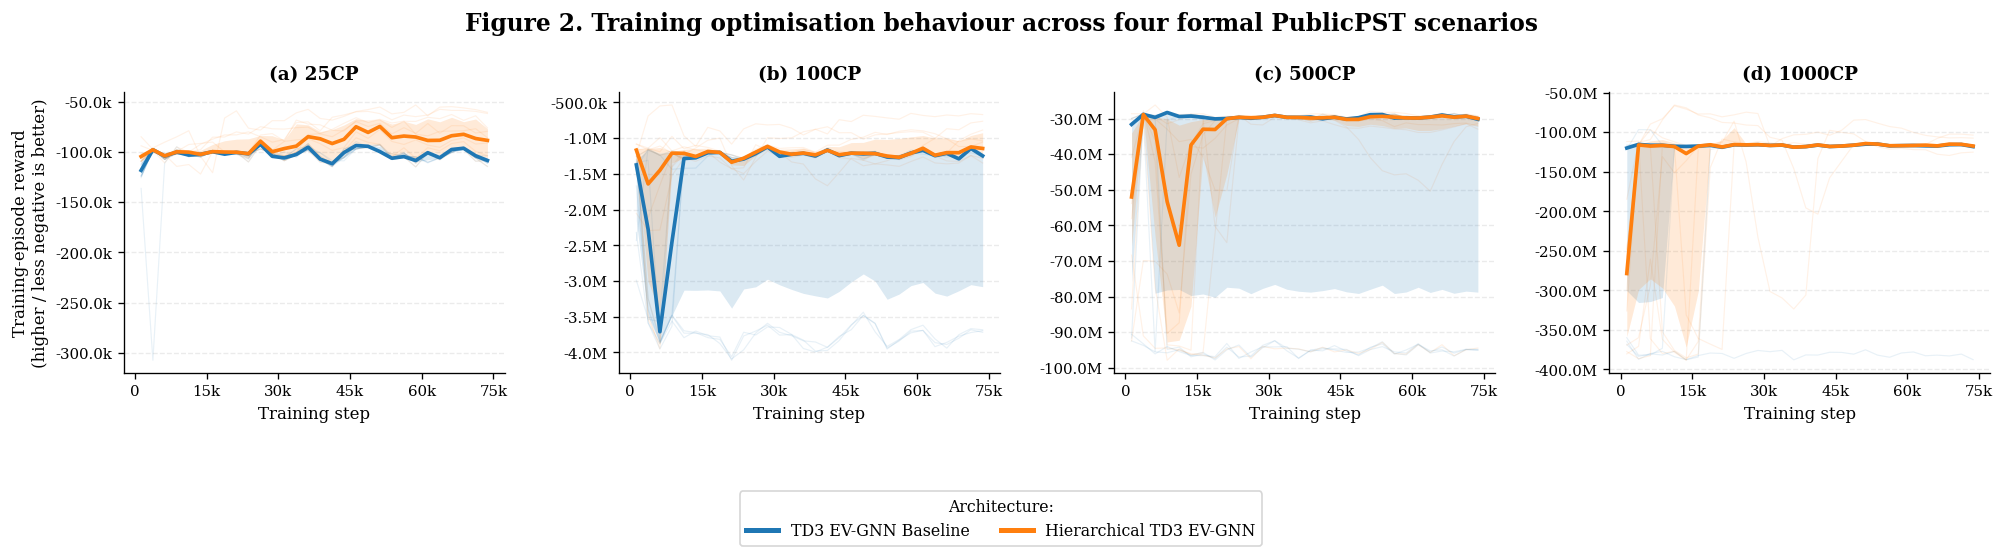

In [6]:
train_episode["step_bin"] = pd.cut(
    train_episode["timestep"],
    bins=np.linspace(0, 75000, 31),
    labels=False,
    include_lowest=True,
)

seed_binned = (
    train_episode
    .groupby(["scale", "model", "training_seed", "step_bin"], observed=True)
    .agg(timestep=("timestep", "mean"), episode_reward=("episode_reward", "median"))
    .reset_index()
)

fig, axes = plt.subplots(1, 4, figsize=(17, 4.5), sharex=True)
fig.subplots_adjust(left=0.07, right=0.985, top=0.80, bottom=0.28, wspace=0.30)

for panel, (ax, scale) in enumerate(zip(axes, SCALE_ORDER)):
    for model in MODEL_ORDER:
        d = seed_binned[(seed_binned["scale"] == scale) & (seed_binned["model"] == model)]

        for _, seed_curve in d.groupby("training_seed"):
            seed_curve = seed_curve.sort_values("timestep")
            ax.plot(
                seed_curve["timestep"],
                seed_curve["episode_reward"],
                color=MODEL_COLOUR[model],
                linewidth=0.7,
                alpha=0.10,
                zorder=1,
            )

        summary = (
            d.groupby("step_bin")
             .agg(
                 timestep=("timestep", "mean"),
                 centre=("episode_reward", "median"),
                 q25=("episode_reward", lambda x: x.quantile(0.25)),
                 q75=("episode_reward", lambda x: x.quantile(0.75)),
             )
             .reset_index()
        )

        ax.fill_between(
            summary["timestep"],
            summary["q25"],
            summary["q75"],
            color=MODEL_COLOUR[model],
            alpha=0.16,
            linewidth=0,
            zorder=2,
        )
        ax.plot(
            summary["timestep"],
            summary["centre"],
            color=MODEL_COLOUR[model],
            linewidth=2.2,
            zorder=3,
        )

    ax.set_title(f"({chr(97 + panel)}) {SCALE_LABELS[scale]}", pad=8)
    ax.set_xlabel("Training step")
    ax.set_xticks(
        [0, 15000, 30000, 45000, 60000, 75000],
        ["0", "15k", "30k", "45k", "60k", "75k"],
    )
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    ax.yaxis.set_major_formatter(COMPACT_FORMATTER)

axes[0].set_ylabel("Training-episode reward\n(higher / less negative is better)")

fig.suptitle(
    "Figure 2. Training optimisation behaviour across four formal PublicPST scenarios",
    fontsize=14,
    fontweight="bold",
    y=0.95,
)
model_legend(fig, y=-0.055)
plt.show()


- 淡色細線：10 個獨立 training seeds 各自的 binned training trajectory。
- 粗藍 / 粗橘線：同一 architecture 在每個 bin 上，10 個 seed trajectories 的 cross-seed median。
- 半透明色帶：10 個 seed 在該 training bin 的 25th–75th percentile，也就是 IQR / middle 50%。

### How to read the training comparison in plain language

Both architectures are trained with the same TD3 framework, reward definition, training budget, and formal PublicPST scenarios. Figure 2 therefore asks a narrow question: **how does optimisation behave when the action is formed directly at EV level versus when it is factorised through transformer and charger levels?**

The thin trajectories show individual training seeds. The bold line shows the cross-seed median after summarising episodes in 2,500-step bins, and the shaded region shows the middle 50% of seeds.

A useful way to read the figure is:

- a **higher** trajectory means less-negative training reward and therefore better reward under the current PublicPST objective;
- a **narrower** seed band means the independent training runs are behaving more similarly at that point in training;
- a **wide** band or isolated trajectory indicates stronger seed sensitivity;
- improvement late in the budget suggests that useful optimisation is still occurring, while a flat or deteriorating late trajectory suggests that later updates are not consistently improving training reward.

These are optimisation observations, not the final architecture comparison. Exploration is still active during training episodes, so the next section uses deterministic scheduled evaluations to ask what the policy itself has learned.


In [7]:
# Descriptive late-training comparison: final 15,000 training steps
late = train_episode[train_episode["timestep"] >= 60000]
late_seed = (
    late.groupby(["scale", "model", "training_seed"])["episode_reward"]
        .median()
        .reset_index()
)

late_rows = []
for scale in SCALE_ORDER:
    g = late_seed[late_seed["scale"] == scale]
    baseline = g[g["model"] == MODEL_ORDER[0]]["episode_reward"].median()
    hierarchy = g[g["model"] == MODEL_ORDER[1]]["episode_reward"].median()
    benefit = hierarchy - baseline
    late_rows.append({
        "Scenario": SCALE_LABELS[scale],
        "Baseline late-training median": reward_text(baseline),
        "Hierarchy late-training median": reward_text(hierarchy),
        "Hierarchy - baseline": reward_text(benefit),
        "Relative difference": f"{100 * benefit / abs(baseline):+.1f}%",
    })

display(Markdown(markdown_table(pd.DataFrame(late_rows))))

better_count = sum(
    float(
        late_seed[(late_seed["scale"] == s) & (late_seed["model"] == MODEL_ORDER[1])]["episode_reward"].median()
        -
        late_seed[(late_seed["scale"] == s) & (late_seed["model"] == MODEL_ORDER[0])]["episode_reward"].median()
    ) > 0
    for s in SCALE_ORDER
)



| Scenario | Baseline late-training median | Hierarchy late-training median | Hierarchy - baseline | Relative difference |
| --- | --- | --- | --- | --- |
| 25CP | -102.6k | -85.2k | 17.4k | +17.0% |
| 100CP | -1.2M | -1.2M | 71.2k | +5.8% |
| 500CP | -29.5M | -29.5M | 1.4k | +0.0% |
| 1000CP | -116.8M | -116.7M | 23.1k | +0.0% |

Observed optimisation pattern. Across the final 15,000 training steps, the hierarchical architecture has the higher cross-seed median training reward in 4 of 4 formal scenarios. The table reports the scale-specific magnitude. These values describe optimisation behaviour only; training episodes are correlated within runs and should not be treated as independent final-performance replicates.

## Figure 3A - Scheduled-evaluation learning curves

Training-episode reward is affected by exploration and ongoing parameter updates. Scheduled deterministic evaluation provides a cleaner view of how the policy itself changed over training. Every 5,000 steps, each run is evaluated for five deterministic episodes; Figure 3A then summarises the resulting evaluation reward across the ten independently trained seeds.

For each checkpoint, the solid line is the **mean across ten training seeds** and the shaded region is a **95% confidence interval across those seeds**. Higher / less-negative reward means better PublicPST objective performance.

**How to read the figure.** The vertical position shows policy quality at a particular checkpoint; the slope shows whether that quality improved or deteriorated as training continued; the width of the confidence band shows how consistently the ten independent training seeds behaved. Figure 3A should therefore be used to judge the timing and stability of learning, not to replace the independent `model.best` evaluation used for the final architecture comparison.


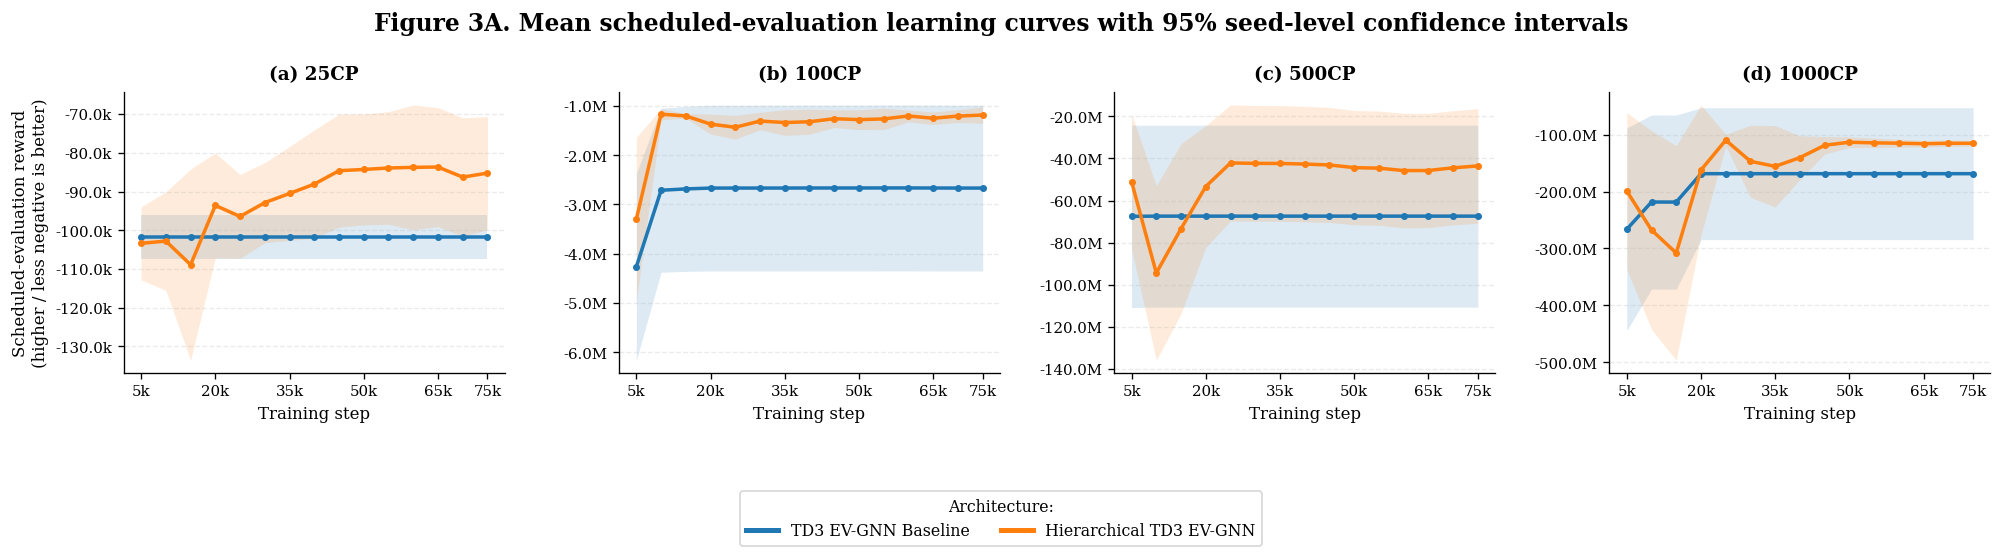

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4.5), sharex=True)
fig.subplots_adjust(left=0.07, right=0.985, top=0.80, bottom=0.28, wspace=0.30)

for panel, (ax, scale) in enumerate(zip(axes, SCALE_ORDER)):
    for model in MODEL_ORDER:
        d = scheduled[(scheduled["scale"] == scale) & (scheduled["model"] == model)]
        rows = []
        for step, g in d.groupby("timestep"):
            mean, low, high = mean_ci95(g["eval/mean_reward"])
            rows.append((step, mean, low, high))

        summary = pd.DataFrame(rows, columns=["step", "mean", "low", "high"]).sort_values("step")
        ax.plot(
            summary["step"],
            summary["mean"],
            marker="o",
            markersize=3.2,
            linewidth=2.1,
            color=MODEL_COLOUR[model],
        )
        ax.fill_between(
            summary["step"],
            summary["low"],
            summary["high"],
            color=MODEL_COLOUR[model],
            alpha=0.15,
            linewidth=0,
        )

    ax.set_title(f"({chr(97 + panel)}) {SCALE_LABELS[scale]}", pad=8)
    ax.set_xlabel("Training step")
    ax.set_xticks(
        [5000, 20000, 35000, 50000, 65000, 75000],
        ["5k", "20k", "35k", "50k", "65k", "75k"],
    )
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    ax.yaxis.set_major_formatter(COMPACT_FORMATTER)

axes[0].set_ylabel("Scheduled-evaluation reward\n(higher / less negative is better)")

fig.suptitle(
    "Figure 3A. Mean scheduled-evaluation learning curves with 95% seed-level confidence intervals",
    fontsize=14,
    fontweight="bold",
    y=0.95,
)
model_legend(fig, y=-0.055)
plt.show()


### Scheduled evaluation in plain language

Think of the scheduled evaluation as a fixed test given every 5,000 training steps. During this test, exploration noise is removed and the current policy is run deterministically for five episodes. This makes the curve easier to interpret than raw training reward because it focuses on the policy obtained at that checkpoint rather than on the noisy reward collected while learning.

For each checkpoint:

- the solid line is the average deterministic evaluation reward across the ten independently trained seeds;
- the shaded band is the 95% confidence interval across those seed-level evaluations;
- moving upward means the current policies are, on average, achieving less-negative reward;
- a wide band means different training seeds have reached materially different policy quality.

The main question is not simply "which line is higher at 75k?" The shape of the curve also shows **when** each architecture tends to find favourable deterministic policies and how much seed-to-seed variation remains while training proceeds.


In [9]:
# Final scheduled checkpoint (75k) - descriptive, not the final model.best evaluation
final_step = int(scheduled["timestep"].max())
final_sched = scheduled[scheduled["timestep"] == final_step]

rows = []
for scale in SCALE_ORDER:
    scale_rows = {"Scenario": SCALE_LABELS[scale]}
    raw = {}
    for model in MODEL_ORDER:
        values = final_sched[
            (final_sched["scale"] == scale) & (final_sched["model"] == model)
        ]["eval/mean_reward"]
        mean, low, high = mean_ci95(values)
        raw[model] = mean
        scale_rows[model] = f"{reward_text(mean)} [{reward_text(low)}, {reward_text(high)}]"
    benefit = raw[MODEL_ORDER[1]] - raw[MODEL_ORDER[0]]
    scale_rows["Hierarchy - baseline"] = reward_text(benefit)
    scale_rows["Relative difference"] = f"{100 * benefit / abs(raw[MODEL_ORDER[0]]):+.1f}%"
    rows.append(scale_rows)

display(Markdown(
    f"**Scheduled evaluation at {final_step // 1000}k training steps** "
    "(mean [95% seed-level CI]; this is not the independent `model.best` eval30):"
))
display(Markdown(markdown_table(pd.DataFrame(rows))))

n_higher = sum(
    final_sched[(final_sched["scale"] == s) & (final_sched["model"] == MODEL_ORDER[1])]["eval/mean_reward"].mean()
    >
    final_sched[(final_sched["scale"] == s) & (final_sched["model"] == MODEL_ORDER[0])]["eval/mean_reward"].mean()
    for s in SCALE_ORDER
)


**Scheduled evaluation at 75k training steps** (mean [95% seed-level CI]; this is not the independent `model.best` eval30):

| Scenario | TD3 EV-GNN Baseline | Hierarchical TD3 EV-GNN | Hierarchy - baseline | Relative difference |
| --- | --- | --- | --- | --- |
| 25CP | -101.7k [-107.4k, -96.0k] | -85.2k [-99.8k, -70.6k] | 16.5k | +16.2% |
| 100CP | -2.7M [-4.3M, -984.0k] | -1.2M [-1.4M, -1.0M] | 1.5M | +55.6% |
| 500CP | -67.4M [-110.7M, -24.2M] | -43.6M [-70.8M, -16.3M] | 23.9M | +35.4% |
| 1000CP | -168.6M [-284.5M, -52.7M] | -115.1M [-119.9M, -110.4M] | 53.4M | +31.7% |

The table above reports the deterministic evaluation measured at the **final scheduled checkpoint (75k)**. It is useful for understanding what the two architectures look like at the end of the common training budget, but it is not yet the final selected-policy result.

The distinction matters because the experiment later evaluates each run's selected `model.best` checkpoint independently over 30 deterministic episodes. A policy can therefore have found its best scheduled checkpoint earlier than 75k even if training continued to the full budget.

In plain language, the 75k table answers: *where did each architecture finish?* The checkpoint-selection analysis below asks a different question: *when did each trained seed first reach the scheduled checkpoint that was ultimately best within its own run?*


## Figure 3B - Joint distribution of scheduled-evaluation performance

A mean learning curve can hide how widely the individual seed-checkpoint observations are distributed. Figure 3B therefore shows the **joint distribution of training time and scheduled-evaluation reward** for each architecture. The layout is adapted from the joint-density presentation used in Fig. 4a of Orfanoudakis et al. (2025), but the variables are chosen for the present learning question.

For each PublicPST scenario:

- the **central filled density** shows where the 10 seeds × 15 scheduled checkpoints are concentrated;
- the **x-axis** is the scheduled checkpoint from 5k to 75k training steps;
- the **y-axis** is scheduled-evaluation reward;
- the **right marginal PDF** summarises the reward distribution after the training-time dimension is collapsed;
- the **top marginal PDF** represents the common checkpoint schedule. Because both architectures are evaluated at exactly the same checkpoints, this marginal is shared by design rather than being a performance result.

The four scenarios are plotted separately because their raw reward magnitudes differ substantially. Each architecture contributes 150 seed-checkpoint observations per scenario, but these are repeated measurements from ten trained seeds. Figure 3B is therefore **descriptive learning evidence**, not an inferential sample of $n=150$.

**Reference for the visual form:** Orfanoudakis et al. (2025), Fig. 4a, https://doi.org/10.1038/s44172-025-00457-8. The accompanying EV-GNN repository implements its joint-density figure with filled KDE regions and marginal density curves in `Results_Analysis/generalization_eda.py`.


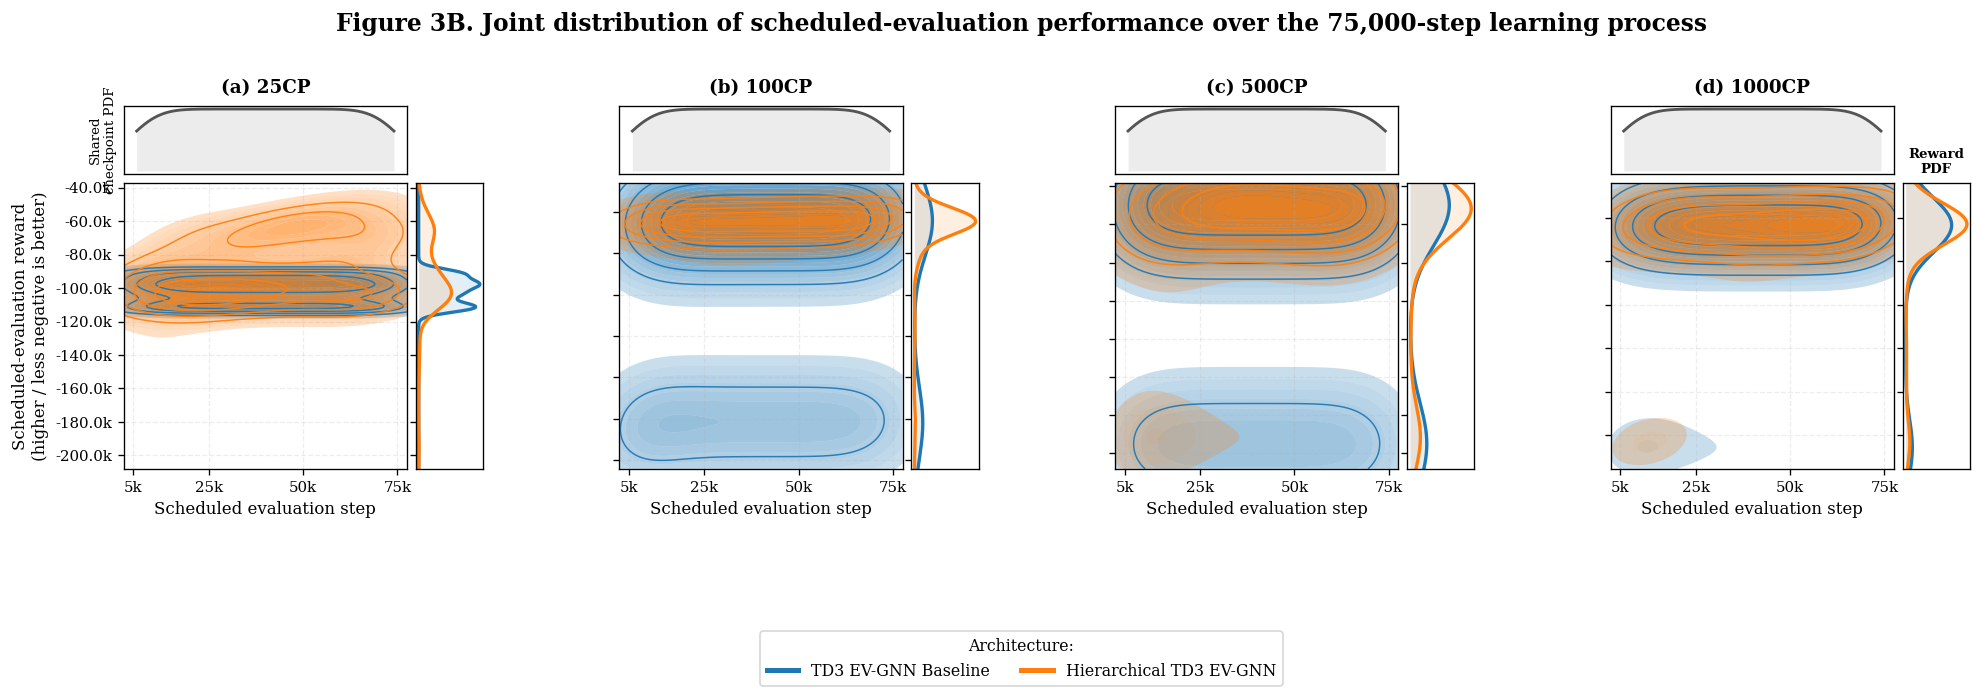

In [10]:
fig = plt.figure(figsize=(17, 5.6))
outer = fig.add_gridspec(
    1, 4,
    left=0.060, right=0.965,
    top=0.82, bottom=0.28,
    wspace=0.38,
)

for panel, scale in enumerate(SCALE_ORDER):
    gs = outer[panel].subgridspec(
        2, 2,
        height_ratios=[1.0, 4.2],
        width_ratios=[4.2, 1.0],
        hspace=0.05,
        wspace=0.05,
    )

    ax_top = fig.add_subplot(gs[0, 0])
    ax_main = fig.add_subplot(gs[1, 0])
    ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)
    ax_blank = fig.add_subplot(gs[0, 1])
    ax_blank.axis("off")

    scale_data = scheduled[scheduled["scale"] == scale]
    x_all = scale_data["timestep"].to_numpy(float)
    y_all = scale_data["eval/mean_reward"].to_numpy(float)

    x_grid = np.linspace(x_all.min() - 2500, x_all.max() + 2500, 180)
    y_range = y_all.max() - y_all.min()
    y_pad = 0.08 * y_range if y_range > 0 else 1.0
    y_grid = np.linspace(y_all.min() - y_pad, y_all.max() + y_pad, 180)

    # Both architectures use the same checkpoint schedule. Plot one neutral top marginal
    # rather than drawing two identical lines on top of one another.
    shared_x_grid = np.linspace(x_all.min(), x_all.max(), 300)
    ax_top.plot(
        shared_x_grid,
        kde1d(x_all, shared_x_grid),
        color="#555555",
        linewidth=1.7,
    )
    ax_top.fill_between(
        shared_x_grid,
        0,
        kde1d(x_all, shared_x_grid),
        color="#BDBDBD",
        alpha=0.28,
        linewidth=0,
    )

    x_loc = x_all.mean()
    x_scale = x_all.std(ddof=1)
    y_loc = y_all.mean()
    y_scale = y_all.std(ddof=1)

    for model in MODEL_ORDER:
        d = scale_data[scale_data["model"] == model]
        X, Y, Z = shared_joint_kde(
            d["timestep"],
            d["eval/mean_reward"],
            x_grid,
            y_grid,
            x_loc,
            x_scale,
            y_loc,
            y_scale,
        )

        # Use a model-relative density threshold so broad and narrow distributions
        # remain visible. Colour intensity indicates density within that architecture.
        peak = float(np.nanmax(Z))
        levels = np.linspace(peak * 0.12, peak, 18)

        ax_main.contourf(
            X, Y, Z,
            levels=levels,
            cmap=alpha_cmap(MODEL_COLOUR[model], min_alpha=0.22, max_alpha=0.88),
            antialiased=True,
        )
        ax_main.contour(
            X, Y, Z,
            levels=np.linspace(peak * 0.30, peak * 0.82, 4),
            colors=[MODEL_COLOUR[model]],
            linewidths=0.9,
            alpha=0.92,
        )

        y_marginal_grid = np.linspace(y_grid.min(), y_grid.max(), 300)
        y_density = kde1d(d["eval/mean_reward"], y_marginal_grid)
        ax_right.plot(
            y_density,
            y_marginal_grid,
            color=MODEL_COLOUR[model],
            linewidth=2.0,
        )
        ax_right.fill_betweenx(
            y_marginal_grid,
            0,
            y_density,
            color=MODEL_COLOUR[model],
            alpha=0.12,
            linewidth=0,
        )

    ax_top.set_title(
        f"({chr(97 + panel)}) {SCALE_LABELS[scale]}",
        pad=8,
        fontweight="semibold",
    )
    ax_main.set_xlabel("Scheduled evaluation step")
    ax_main.set_xlim(x_grid.min(), x_grid.max())
    ax_main.set_xticks(
        [5000, 25000, 50000, 75000],
        ["5k", "25k", "50k", "75k"],
    )
    ax_main.set_ylim(y_grid.min(), y_grid.max())
    ax_main.grid(True, linestyle="--", alpha=0.22)
    ax_main.yaxis.set_major_formatter(COMPACT_FORMATTER)

    if panel == 0:
        ax_main.set_ylabel(
            "Scheduled-evaluation reward\n(higher / less negative is better)"
        )
        ax_top.set_ylabel("Shared\ncheckpoint PDF", fontsize=8)
    else:
        ax_main.tick_params(labelleft=False)

    ax_top.set_xticks([])
    ax_top.set_yticks([])
    ax_right.set_xticks([])
    ax_right.tick_params(labelleft=False)

    if panel == len(SCALE_ORDER) - 1:
        ax_right.set_title("Reward\nPDF", fontsize=8, pad=6)

    for axis in (ax_top, ax_main, ax_right):
        for spine in axis.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(0.8)

fig.suptitle(
    "Figure 3B. Joint distribution of scheduled-evaluation performance over the 75,000-step learning process",
    fontsize=14,
    fontweight="bold",
    y=0.96,
)
model_legend(fig, y=-0.055)
plt.show()


**How to read Figure 3B.** Focus first on the vertical position of the filled density. A body concentrated higher on the reward axis means more of that architecture's scheduled evaluations occupied a favourable reward range. A body that is vertically broad or split into separated regions means the training seeds and checkpoints occupied more heterogeneous performance regimes.

The horizontal axis adds the timing information. If favourable density appears mainly late in training, the better evaluations were concentrated toward later checkpoints. If favourable and adverse regions both persist across the training range, optimisation is more heterogeneous.

The right-hand marginal density removes the checkpoint dimension and shows the overall distribution of scheduled-evaluation reward for that architecture within the scenario. Because every seed is evaluated on the same 5k-to-75k schedule, the top marginal is shared by design and should not be read as an architecture result.

Figure 3B is therefore a **descriptive map of where the learning process spent its evaluation history**. It complements Figure 3A by showing structure that can be hidden by a mean curve.


### A more intuitive way to read the density map

A useful mental model is a heatmap of the policy's repeated "test scores" during training.

- A **dense high-reward region** means many seed-checkpoint evaluations landed in a similar favourable reward band.
- A **dense low-reward region** means many evaluations occupied a poor-reward regime.
- **Multiple separated regions** suggest that different seeds or checkpoints settled into qualitatively different performance regimes.
- A **narrow right-hand reward density** means the scheduled evaluations are concentrated in a relatively small reward range; a broad or multi-modal density means greater heterogeneity.

This does not by itself prove that one architecture will be better after model selection. The same seed contributes fifteen scheduled evaluations, so Figure 3B is a view of the learning process rather than an independent-sample hypothesis test. Its value is that it shows whether the two architectures reach similar or very different reward regimes while the 75,000-step optimisation unfolds.


In [11]:
# Checkpoint-selection robustness
best_rows = []
for (scale, model, seed), g in scheduled.groupby(["scale", "model", "training_seed"]):
    best_idx = g["eval/mean_reward"].idxmax()
    best_rows.append({
        "scale": scale,
        "model": model,
        "training_seed": seed,
        "best_step": int(g.loc[best_idx, "timestep"]),
    })

best_checkpoints = pd.DataFrame(best_rows)
best_checkpoints["scale"] = pd.Categorical(
    best_checkpoints["scale"], categories=SCALE_ORDER, ordered=True
)
best_checkpoints["model"] = pd.Categorical(
    best_checkpoints["model"], categories=MODEL_ORDER, ordered=True
)

summary_rows = []
short_name = {
    MODEL_ORDER[0]: "Baseline",
    MODEL_ORDER[1]: "Hierarchical",
}

for scale in SCALE_ORDER:
    for model in MODEL_ORDER:
        g = best_checkpoints[
            (best_checkpoints["scale"] == scale)
            & (best_checkpoints["model"] == model)
        ]
        q1, q3 = g["best_step"].quantile([0.25, 0.75])
        summary_rows.append({
            "Scenario": SCALE_LABELS[scale],
            "Architecture": short_name[model],
            "Median best checkpoint": f"{int(g['best_step'].median() / 1000)}k",
            "IQR": f"{int(q1 / 1000)}k-{int(q3 / 1000)}k",
            "Best at 5k": f"{int((g['best_step'] == 5000).sum())}/10",
            "Best <=25k": f"{int((g['best_step'] <= 25000).sum())}/10",
            "Best >50k": f"{int((g['best_step'] > 50000).sum())}/10",
        })

checkpoint_summary = pd.DataFrame(summary_rows)
display(Markdown("### Checkpoint-selection robustness"))
display(Markdown(markdown_table(checkpoint_summary)))

first_checkpoint_text = []
for scale in SCALE_ORDER:
    b = best_checkpoints[
        (best_checkpoints["scale"] == scale)
        & (best_checkpoints["model"] == MODEL_ORDER[0])
    ]
    h = best_checkpoints[
        (best_checkpoints["scale"] == scale)
        & (best_checkpoints["model"] == MODEL_ORDER[1])
    ]
    first_checkpoint_text.append(
        f"**{SCALE_LABELS[scale]}:** baseline {int((b.best_step == 5000).sum())}/10 at 5k "
        f"versus hierarchy {int((h.best_step == 5000).sum())}/10; "
        f"median best checkpoint {int(b.best_step.median()/1000)}k versus "
        f"{int(h.best_step.median()/1000)}k."
    )

### Checkpoint-selection robustness

| Scenario | Architecture | Median best checkpoint | IQR | Best at 5k | Best <=25k | Best >50k |
| --- | --- | --- | --- | --- | --- | --- |
| 25CP | Baseline | 5k | 5k-5k | 10/10 | 10/10 | 0/10 |
| 25CP | Hierarchical | 60k | 47k-68k | 2/10 | 2/10 | 7/10 |
| 100CP | Baseline | 5k | 5k-10k | 6/10 | 9/10 | 1/10 |
| 100CP | Hierarchical | 30k | 15k-55k | 0/10 | 5/10 | 4/10 |
| 500CP | Baseline | 5k | 5k-5k | 8/10 | 10/10 | 0/10 |
| 500CP | Hierarchical | 25k | 8k-50k | 3/10 | 6/10 | 3/10 |
| 1000CP | Baseline | 5k | 5k-8k | 7/10 | 10/10 | 0/10 |
| 1000CP | Hierarchical | 10k | 5k-32k | 4/10 | 7/10 | 2/10 |

### Reading checkpoint selection

The table above asks **when each trained seed first reached its best scheduled deterministic evaluation** within the 75,000-step budget.

- **Median best checkpoint** gives the middle selected step across the ten seeds.
- **IQR** shows how widely checkpoint selection varies across seeds.
- **Best at 5k** identifies runs whose first scheduled evaluation was never exceeded later.
- **Best $\leq$25k** indicates how often the best scheduled policy appeared in the first third of training.
- **Best $>50$k** indicates how often useful improvement continued into the later part of the budget.

A later selected checkpoint is not automatically "better convergence", and an early selected checkpoint is not automatically a failure. The table is more useful as an optimisation-timing diagnostic: it shows whether the two action-forming structures tend to locate their best deterministic policy at similar or different points in the common training budget.


# Final selected-checkpoint performance

The training section described optimisation and checkpoint selection. The evidence layer now changes: every result below uses the independently evaluated `model.best` policy.

For each trained seed $s$, the 30 deterministic evaluation episodes are first averaged,

$$
\bar y_s=\frac{1}{30}\sum_{e=1}^{30}y_{s,e},
$$

and architecture effects are then compared across the **10 paired training seeds**. The inferential unit is therefore $n=10$ per formal scenario. Episode-level observations are still shown in selected figures because they reveal within-policy variability, but they are **descriptive background observations rather than additional independent training replicates**.

The main selected-policy analysis keeps four questions separate:

- **Episode reward — control efficacy.** Higher, less-negative reward is better under the PublicPST objective.
- **Power-tracker violation — tracking reliability.** Lower means less violation of the permitted tracking region.
- **Maximum active-EV action fraction — decision behaviour.** Lower means less upper-bound saturation, but this is not independently equivalent to better control.
- **Transformer overload — infrastructure consequence.** Lower is operationally preferable.

EV-service outcomes are examined separately so that a control improvement is not described as operationally better if it is obtained by materially reducing charging service.

### How the final selected-policy comparison is constructed

The analysis now moves from learning behaviour to the selected `model.best` policies.

Two independent evidence layers are loaded:

- **final eval30** for reward, tracking, energy tracking, power-tracker violation, satisfaction, energy delivered, and EVs served;
- **infrastructure diagnostics** for action composition, transformer overload, and allocation-concentration metrics.

For every architecture, scenario, and training seed, the 30 deterministic episodes are averaged into one **trained-policy estimate**. The baseline and hierarchical policies carrying the same training-seed label are then paired.

In plain language, the 30 episodes tell us how one selected policy behaves across repeated deterministic test episodes; the ten independently trained seeds tell us how reproducible the architectural effect is across independent training runs. The formal comparison therefore uses the ten paired trained-policy means, not 300 episode rows as if they were 300 independently trained controllers.


In [12]:
# Load the independent selected-policy evaluation and infrastructure-diagnostic episodes.
EVAL_RE = re.compile(
    r"^.*formal75k_eval30_(?P<scale>\d+cp)_(?P<algorithm>actiongnn_nonnegative|hierarchical)"
    r"_seed(?P<seed>\d+)_.*\.tar\.gz$"
)
DIAG_RE = re.compile(
    r"^.*formal75k_diagnostics_(?P<scale>\d+cp)_(?P<algorithm>actiongnn_nonnegative|hierarchical)"
    r"_seed(?P<seed>\d+)_.*\.tar\.gz$"
)

def load_selected_policy_episodes(pattern, suffix, row_type=None):
    frames = []
    for path in sorted(DATA_ROOT.rglob("*.tar.gz")):
        match = pattern.match(path.name)
        if not match:
            continue
        with tarfile.open(path, "r:gz") as tf:
            frame = pd.read_csv(io.BytesIO(read_member(tf, suffix)))
        if row_type is not None:
            frame = frame[frame["row_type"].eq(row_type)].copy()
        frame["scale"] = match["scale"]
        frame["algorithm"] = match["algorithm"]
        frame["model"] = MODEL_LABELS[match["algorithm"]]
        frame["training_seed"] = int(match["seed"])
        frames.append(frame)
    return pd.concat(frames, ignore_index=True)

eval30 = load_selected_policy_episodes(EVAL_RE, "_eval30.csv", row_type="episode")
diagnostics = load_selected_policy_episodes(DIAG_RE, "diagnostics/episode_diagnostics.csv")


In [13]:
# Average the 30 episodes within each trained policy, then form same-seed architecture effects.
group_keys = ["scale", "algorithm", "model", "training_seed"]

eval_metrics = [
    "episode_reward", "tracking_error", "energy_tracking_error",
    "power_tracker_violation", "average_user_satisfaction",
    "total_energy_charged", "total_ev_served",
]
diag_metrics = [
    "global_action_fraction_at_max_active", "global_zero_action_fraction_active",
    "transformer_positive_charge_action_hhi_mean",
    "transformer_positive_charge_action_gini_mean",
    "charger_positive_charge_action_hhi_mean",
    "charger_positive_charge_action_gini_mean",
    "total_transformer_overload",
]

seed_eval = eval30.groupby(group_keys, observed=True)[eval_metrics].mean().reset_index()
seed_diag = diagnostics.groupby(group_keys, observed=True)[diag_metrics].mean().reset_index()
seed_performance = seed_eval.merge(seed_diag, on=group_keys)
seed_performance["interior_action_fraction"] = (
    1
    - seed_performance["global_zero_action_fraction_active"]
    - seed_performance["global_action_fraction_at_max_active"]
).clip(0, 1)
seed_performance["scale"] = pd.Categorical(
    seed_performance["scale"], categories=SCALE_ORDER, ordered=True
)
seed_performance["model"] = pd.Categorical(
    seed_performance["model"], categories=MODEL_ORDER, ordered=True
)

def paired_seed_effects(seed_df):
    rows = []
    for scale in SCALE_ORDER:
        b = seed_df[(seed_df["scale"] == scale) & (seed_df["model"] == MODEL_ORDER[0])].set_index("training_seed")
        h = seed_df[(seed_df["scale"] == scale) & (seed_df["model"] == MODEL_ORDER[1])].set_index("training_seed")
        seeds = b.index.intersection(h.index)
        b_ref = b.loc[seeds].mean(numeric_only=True)

        for seed in seeds:
            bs, hs = b.loc[seed], h.loc[seed]
            rows.append({
                "scale": scale,
                "training_seed": int(seed),
                "reward_benefit": hs["episode_reward"] - bs["episode_reward"],
                "reward_benefit_pct": 100 * (hs["episode_reward"] - bs["episode_reward"]) / abs(b_ref["episode_reward"]),
                "energy_tracking_reduction": bs["energy_tracking_error"] - hs["energy_tracking_error"],
                "energy_tracking_reduction_pct": 100 * (bs["energy_tracking_error"] - hs["energy_tracking_error"]) / abs(b_ref["energy_tracking_error"]),
                "power_violation_reduction": bs["power_tracker_violation"] - hs["power_tracker_violation"],
                "power_violation_reduction_pct": 100 * (bs["power_tracker_violation"] - hs["power_tracker_violation"]) / abs(b_ref["power_tracker_violation"]),
                "max_action_reduction_pp": 100 * (bs["global_action_fraction_at_max_active"] - hs["global_action_fraction_at_max_active"]),
                "zero_action_change_pp": 100 * (hs["global_zero_action_fraction_active"] - bs["global_zero_action_fraction_active"]),
                "interior_action_change_pp": 100 * (hs["interior_action_fraction"] - bs["interior_action_fraction"]),
                "overload_reduction": bs["total_transformer_overload"] - hs["total_transformer_overload"],
                "satisfaction_change_pp": 100 * (hs["average_user_satisfaction"] - bs["average_user_satisfaction"]),
                "energy_delivered_change": hs["total_energy_charged"] - bs["total_energy_charged"],
            })

    out = pd.DataFrame(rows)
    out["scale"] = pd.Categorical(out["scale"], categories=SCALE_ORDER, ordered=True)
    return out.sort_values(["scale", "training_seed"]).reset_index(drop=True)

paired = paired_seed_effects(seed_performance)


### Plotting the selected-policy evidence

The helper functions below keep two levels of variation visible in the final-policy figures. Episode distributions show how one selected policy behaves across its repeated deterministic episodes, while the paired seed-level points show the independently trained policies that form the inferential sample.


In [14]:
# Visualisation utilities for selected-policy comparisons.
# Episode distributions are descriptive; formal inference remains at the paired seed level.

MODEL_TICK_LABELS = ["TD3 EV-GNN\nBaseline", "Hierarchical\nTD3 EV-GNN"]

def paired_seed_series(seed_frame, scale, metric):
    b = (
        seed_frame[(seed_frame["scale"] == scale) & (seed_frame["model"] == MODEL_ORDER[0])]
        .set_index("training_seed")[metric]
        .sort_index()
    )
    h = (
        seed_frame[(seed_frame["scale"] == scale) & (seed_frame["model"] == MODEL_ORDER[1])]
        .set_index("training_seed")[metric]
        .sort_index()
    )
    seeds = b.index.intersection(h.index)
    return seeds, b.loc[seeds], h.loc[seeds]

def paired_violin(ax, episode_frame, seed_frame, metric, percent=False):
    for x, model in enumerate(MODEL_ORDER):
        episode_values = episode_frame[episode_frame["model"] == model][metric].dropna().to_numpy(float)
        seed_values = seed_frame[seed_frame["model"] == model][metric].dropna().to_numpy(float)
        if percent:
            episode_values = 100 * episode_values
            seed_values = 100 * seed_values

        violin = ax.violinplot(
            [episode_values], positions=[x], widths=0.72,
            showmeans=False, showmedians=True, showextrema=False,
        )
        for body in violin["bodies"]:
            body.set_facecolor(MODEL_COLOUR[model])
            body.set_edgecolor(MODEL_COLOUR[model])
            body.set_alpha(0.18)
        violin["cmedians"].set_color(MODEL_COLOUR[model])
        violin["cmedians"].set_linewidth(1.4)

    seeds, b, h = paired_seed_series(seed_frame, seed_frame["scale"].iloc[0], metric)
    offsets = np.linspace(-0.055, 0.055, len(seeds))
    b_vals = b.to_numpy(float)
    h_vals = h.to_numpy(float)
    if percent:
        b_vals, h_vals = 100 * b_vals, 100 * h_vals

    for off, bv, hv in zip(offsets, b_vals, h_vals):
        ax.plot([0 + off, 1 + off], [bv, hv], color="0.72", linewidth=0.8, alpha=0.8, zorder=2)
        ax.scatter(0 + off, bv, s=32, color=MODEL_COLOUR[MODEL_ORDER[0]],
                   edgecolor="white", linewidth=0.45, zorder=3)
        ax.scatter(1 + off, hv, s=32, color=MODEL_COLOUR[MODEL_ORDER[1]],
                   edgecolor="white", linewidth=0.45, zorder=3)

    ax.set_xticks([0, 1], MODEL_TICK_LABELS)
    ax.grid(axis="y", alpha=0.14)

def seed_box_points(ax, scale, metric, ylabel, percent=True):
    width = 0.28
    centres = np.arange(len(SCALE_ORDER), dtype=float)
    for model_idx, model in enumerate(MODEL_ORDER):
        offset = (-0.17 if model_idx == 0 else 0.17)
        positions = centres + offset
        data = []
        for s in SCALE_ORDER:
            values = seed_performance[
                (seed_performance["scale"] == s) & (seed_performance["model"] == model)
            ][metric].to_numpy(float)
            data.append(100 * values if percent else values)

        bp = ax.boxplot(
            data, positions=positions, widths=width, patch_artist=True,
            showfliers=False, manage_ticks=False,
        )
        for patch in bp["boxes"]:
            patch.set_facecolor(MODEL_COLOUR[model])
            patch.set_alpha(0.18)
            patch.set_edgecolor(MODEL_COLOUR[model])
        for key in ("whiskers", "caps", "medians"):
            for item in bp[key]:
                item.set_color(MODEL_COLOUR[model])

        for x, values in zip(positions, data):
            jitter = np.linspace(-0.045, 0.045, len(values))
            ax.scatter(
                x + jitter, values, s=25, color=MODEL_COLOUR[model],
                edgecolor="white", linewidth=0.4, zorder=3,
            )

    ax.set_xticks(centres, [SCALE_LABELS[s] for s in SCALE_ORDER])
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.14)

def paired_difference_limits(x, y):
    values = np.r_[np.asarray(x, float), np.asarray(y, float), [0.0]]
    lo, hi = np.nanmin(values), np.nanmax(values)
    span = max(hi - lo, max(abs(lo), abs(hi)) * 0.15, 1e-9)
    return lo - 0.10 * span, hi + 0.10 * span


## Figure 4 - Selected-policy performance across control, decision and infrastructure dimensions

Figure 4 compares the **TD3 EV-GNN Baseline** directly with the **Hierarchical TD3 EV-GNN** under each formal scenario.

Each panel contains two evidence layers:

- the **light violin** contains all 300 independent-evaluation episode outcomes for one architecture and scenario and therefore shows descriptive within-policy variability;
- the **large coloured circles** are the 10 independently trained seed-level policy means used in formal paired inference;
- the **thin grey connector** joins the baseline and hierarchical result from the same training seed.

The architecture names are written explicitly on the horizontal axis. Each scenario deliberately keeps its **own vertical scale**, because raw reward, tracking-violation and overload magnitudes change substantially with scenario size. The tick labels use compact `k/M/B` notation rather than scientific-notation multipliers. The correct comparison is **between the two architectures within the same scenario**, not the absolute vertical position of different scenarios.

- **Episode reward:** higher / less negative is better.
- **Power-tracker violation:** lower is better.
- **Maximum active-EV action fraction:** lower means less upper-bound saturation; this is a behavioural change rather than an unconditional utility improvement.
- **Transformer overload:** lower is operationally preferable.


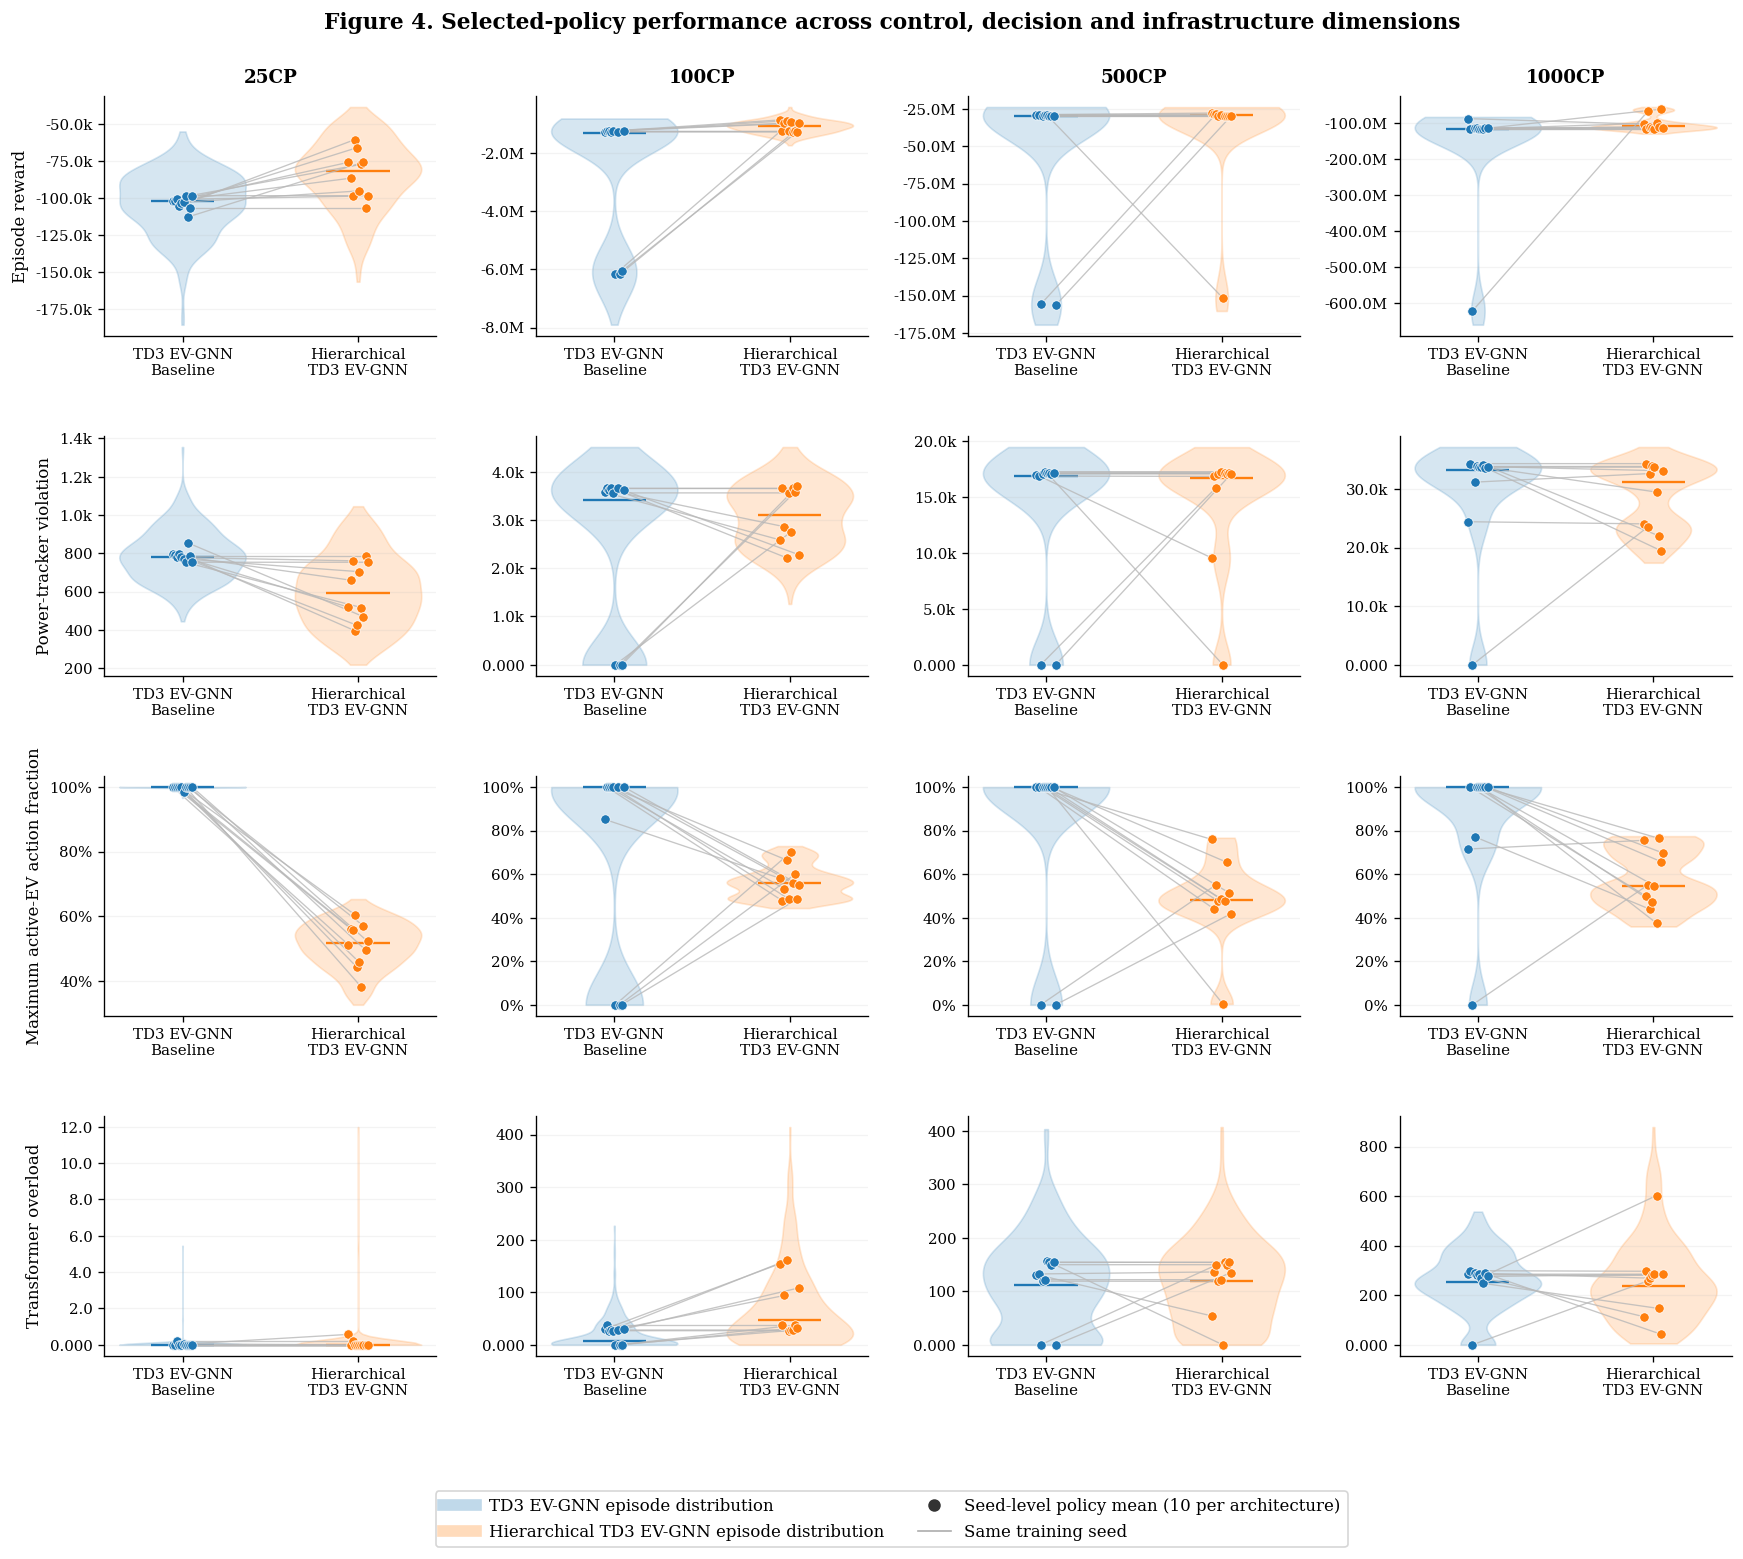

In [15]:
# Figure 4: episode distributions, paired seed means and same-seed connectors.
figure4_specs = [
    ("episode_reward", eval30, "Episode reward", False, COMPACT_FORMATTER),
    ("power_tracker_violation", eval30, "Power-tracker violation", False, COMPACT_FORMATTER),
    ("global_action_fraction_at_max_active", diagnostics, "Maximum active-EV action fraction", True, None),
    ("total_transformer_overload", diagnostics, "Transformer overload", False, COMPACT_FORMATTER),
]

fig, axes = plt.subplots(4, 4, figsize=(17.5, 12.8))
for row, (metric, episode_source, label, percent, formatter) in enumerate(figure4_specs):
    for col, scale in enumerate(SCALE_ORDER):
        ax = axes[row, col]
        paired_violin(
            ax,
            episode_source[episode_source["scale"] == scale],
            seed_performance[seed_performance["scale"] == scale],
            metric,
            percent=percent,
        )
        if row == 0:
            ax.set_title(SCALE_LABELS[scale], pad=8)
        if col == 0:
            ax.set_ylabel(label)
        if percent:
            ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:.0f}%"))
        elif formatter is not None:
            ax.yaxis.set_major_formatter(formatter)

legend_handles = [
    Line2D([0], [0], color=MODEL_COLOUR[MODEL_ORDER[0]], lw=7, alpha=0.28,
           label="TD3 EV-GNN episode distribution"),
    Line2D([0], [0], color=MODEL_COLOUR[MODEL_ORDER[1]], lw=7, alpha=0.28,
           label="Hierarchical TD3 EV-GNN episode distribution"),
    Line2D([0], [0], marker="o", linestyle="", markersize=6.5, color="0.20",
           label="Seed-level policy mean (10 per architecture)"),
    Line2D([0], [0], color="0.68", linewidth=1.0,
           label="Same training seed"),
]
fig.legend(handles=legend_handles, loc="lower center", bbox_to_anchor=(0.5, -0.01),
           ncol=2, frameon=True)
fig.suptitle(
    "Figure 4. Selected-policy performance across control, decision and infrastructure dimensions",
    fontsize=13, fontweight="bold", y=0.995,
)
fig.subplots_adjust(bottom=0.12, top=0.94, hspace=0.42, wspace=0.30)
plt.show()


Figure 4 compares the final selected policies across four operational dimensions and all four formal scenarios.

### How to read the figure

- **Light violin shapes** show the 300 episode outcomes descriptively for one architecture and scenario.
- **Coloured points** are the 10 independently trained policy means used in the paired analysis.
- **Grey connectors** join the baseline and hierarchical policy carrying the same training-seed label.

Each scenario keeps its own vertical scale because reward, violation, and overload magnitudes differ substantially across configured environments.

### What the four rows show

1. **Episode reward — control efficacy.** Higher / less negative is better. The hierarchy has a higher mean reward at all four formal scenarios, but the seed spread differs substantially by scenario.
2. **Power-tracker violation — tracking reliability.** Lower means fewer violations of the permitted tracking region. The direction is favourable to the hierarchy at some scenarios and adverse at others, so it must be read separately from reward.
3. **Maximum active-EV action fraction — decision behaviour.** The hierarchy uses the upper action boundary much less often. This is a large behavioural change, but lower saturation is not automatically better unless the tracking and service outcomes remain acceptable.
4. **Transformer overload — infrastructure consequence.** Lower is preferable. The overload direction is not consistently hierarchy-favourable, which shows that improved PublicPST control does not automatically solve infrastructure stress.

A useful plain-language interpretation is that the hierarchy changes **how** charging commands are formed much more consistently than it improves every operational outcome. The next sections quantify those effects rather than treating the figure alone as proof.


In [16]:
# Research-facing summary of absolute selected-policy outcomes.
def outcome_text(mean, sd, metric):
    if metric == "global_action_fraction_at_max_active":
        return f"{100*mean:.1f}% ± {100*sd:.1f} pp"
    return f"{compact_number(mean)} ± {compact_number(sd)}"

table_specs = [
    ("Episode reward", "episode_reward", "higher"),
    ("Power-tracker violation", "power_tracker_violation", "lower"),
    ("Maximum active-EV action fraction", "global_action_fraction_at_max_active", "context"),
    ("Transformer overload", "total_transformer_overload", "lower"),
]

rows = []
for scale in SCALE_ORDER:
    for label, metric, direction in table_specs:
        b = seed_performance[(seed_performance["scale"] == scale) & (seed_performance["model"] == MODEL_ORDER[0])][metric]
        h = seed_performance[(seed_performance["scale"] == scale) & (seed_performance["model"] == MODEL_ORDER[1])][metric]
        bm, hm = b.mean(), h.mean()

        if metric == "episode_reward":
            change = hm - bm
            change_text = f"{compact_number(change)} ({100*change/abs(bm):+.1f}%)"
            result = "Hierarchy favourable" if change > 0 else "Baseline favourable"
            preferred = "Higher / less negative"
        elif metric == "power_tracker_violation":
            reduction = bm - hm
            change_text = f"{compact_number(-reduction)} under hierarchy"
            change_text += f" ({-100*reduction/abs(bm):+.1f}%)"
            result = "Hierarchy favourable" if reduction > 0 else "Baseline favourable"
            preferred = "Lower"
        elif metric == "global_action_fraction_at_max_active":
            change_pp = 100 * (hm - bm)
            change_text = f"{change_pp:+.1f} percentage points"
            result = "Less upper-bound saturation" if change_pp < 0 else "More upper-bound saturation"
            preferred = "Context-dependent"
        else:
            change = hm - bm
            change_text = f"{compact_number(change)} under hierarchy"
            result = "Hierarchy favourable" if change < 0 else "Baseline favourable"
            preferred = "Lower"

        rows.append({
            "Scenario": SCALE_LABELS[scale],
            "Outcome": label,
            "TD3 EV-GNN mean ± SD": outcome_text(bm, b.std(ddof=1), metric),
            "Hierarchical TD3 EV-GNN mean ± SD": outcome_text(hm, h.std(ddof=1), metric),
            "Change under hierarchy": change_text,
            "Preferred direction": preferred,
            "Result": result,
        })

display(Markdown("**Absolute selected-policy outcomes (10 trained-policy seed means per architecture):**"))
display(Markdown(markdown_table(pd.DataFrame(rows))))


**Absolute selected-policy outcomes (10 trained-policy seed means per architecture):**

| Scenario | Outcome | TD3 EV-GNN mean ± SD | Hierarchical TD3 EV-GNN mean ± SD | Change under hierarchy | Preferred direction | Result |
| --- | --- | --- | --- | --- | --- | --- |
| 25CP | Episode reward | -103.5k ± 4.2k | -84.3k ± 15.4k | 19.2k (+18.5%) | Higher / less negative | Hierarchy favourable |
| 25CP | Power-tracker violation | 786 ± 28.8 | 598 ± 149 | -187 under hierarchy (-23.8%) | Lower | Hierarchy favourable |
| 25CP | Maximum active-EV action fraction | 99.9% ± 0.5 pp | 51.0% ± 6.8 pp | -48.8 percentage points | Context-dependent | Less upper-bound saturation |
| 25CP | Transformer overload | 0.023 ± 0.058 | 0.075 ± 0.183 | 0.053 under hierarchy | Lower | Baseline favourable |
| 100CP | Episode reward | -2.7M ± 2.4M | -1.1M ± 177.2k | 1.6M (+59.9%) | Higher / less negative | Hierarchy favourable |
| 100CP | Power-tracker violation | 2.5k ± 1.7k | 3.1k ± 608 | 549 under hierarchy (+21.7%) | Lower | Baseline favourable |
| 100CP | Maximum active-EV action fraction | 68.5% ± 47.5 pp | 56.4% ± 7.6 pp | -12.1 percentage points | Context-dependent | Less upper-bound saturation |
| 100CP | Transformer overload | 20.6 ± 14.6 | 70.6 ± 54.2 | 50.0 under hierarchy | Lower | Baseline favourable |
| 500CP | Episode reward | -54.8M ± 53.4M | -41.5M ± 38.7M | 13.3M (+24.3%) | Higher / less negative | Hierarchy favourable |
| 500CP | Power-tracker violation | 13.7k ± 7.2k | 14.5k ± 5.6k | 831 under hierarchy (+6.1%) | Lower | Baseline favourable |
| 500CP | Maximum active-EV action fraction | 80.0% ± 42.2 pp | 47.8% ± 19.6 pp | -32.2 percentage points | Context-dependent | Less upper-bound saturation |
| 500CP | Transformer overload | 112 ± 60.6 | 117 ± 50.9 | 5.3 under hierarchy | Lower | Baseline favourable |
| 1000CP | Episode reward | -164.1M ± 160.8M | -102.5M ± 20.6M | 61.6M (+37.5%) | Higher / less negative | Hierarchy favourable |
| 1000CP | Power-tracker violation | 29.3k ± 10.7k | 28.6k ± 5.7k | -672 under hierarchy (-2.3%) | Lower | Hierarchy favourable |
| 1000CP | Maximum active-EV action fraction | 84.9% ± 31.7 pp | 57.5% ± 13.6 pp | -27.3 percentage points | Context-dependent | Less upper-bound saturation |
| 1000CP | Transformer overload | 252 ± 89.7 | 258 ± 150 | 5.6 under hierarchy | Lower | Baseline favourable |

### Observed selected-policy pattern

Figure 4 shows that the hierarchical architecture does **not** produce one uniformly favourable operational profile.

- **25CP:** the hierarchical policy has a substantially higher mean reward (about **18.5%** relative to the baseline mean magnitude), lower mean power-tracker violation (about **23.8%** lower), and roughly **48.8 percentage points** less maximum-action use. The trade-off is that mean transformer overload is higher.
- **100CP:** mean reward is markedly higher under the hierarchy, but mean power-tracker violation and transformer overload are both higher. This is therefore a control-performance result with an infrastructure/tracking trade-off rather than an unqualified improvement.
- **500CP:** the hierarchical mean reward is higher and maximum-action use is much lower, but reward variability is large and the mean violation/overload outcomes are slightly adverse. The raw distributions therefore remain important.
- **1000CP:** mean reward is higher, mean power-tracker violation is slightly lower, and maximum-action use is reduced, while mean transformer overload is slightly higher and considerably more variable.

The episode distributions in the background explain why seed-level means alone can look sparse, but they do **not** increase the inferential sample size. Whether the reward advantage is statistically robust across independently trained policies is examined next with the ten paired seeds.

### Reading the selected-policy summary in plain language

The table above puts the absolute seed-level outcomes next to the change produced by the hierarchical architecture.

**Reward.** The hierarchical mean is higher / less negative in all four scenarios. The largest percentage changes occur at 100CP and 1000CP, but percentage change alone does not tell us how reproducible those gains are across the ten independent training seeds. That question is addressed by the paired inference in the next section.

**Maximum-action use.** The most consistent structural difference is the reduction in upper-bound charging. The baseline spends a large fraction of active-EV decisions at the maximum action, whereas the hierarchical policy moves a substantial share of those decisions into the interior of the continuous action range.

**Tracking and transformer stress.** These do not move together in a single favourable direction. Some scenarios show better tracking under the hierarchy while transformer overload is unchanged or worse. This is an important result rather than a contradiction: the PublicPST control objective and infrastructure stress are related but distinct quantities.

The main research question is therefore not "does the hierarchy win every metric?" It is whether the factorised decision structure produces a reproducible control mechanism and whether that mechanism translates into better selected-policy outcomes without unacceptable infrastructure or service trade-offs.


# Paired architecture effects and formal inference

Figure 5 shows the pairing without first transforming the data into an abstract effect axis. Each row is one independently trained seed. The blue point is that seed's `model.best` reward under the **TD3 EV-GNN Baseline**, the orange point is the reward under the **Hierarchical TD3 EV-GNN**, and the grey segment joins the same seed pair.

Because reward is negative in these experiments, a point farther to the **right** is better: it is higher / less negative. The figure therefore answers a direct question:

> **For each independently trained seed, which architecture produced the better selected-policy reward?**

The mean paired improvement and its 95% confidence interval are reported in Table 2 rather than mixed into the figure legend.


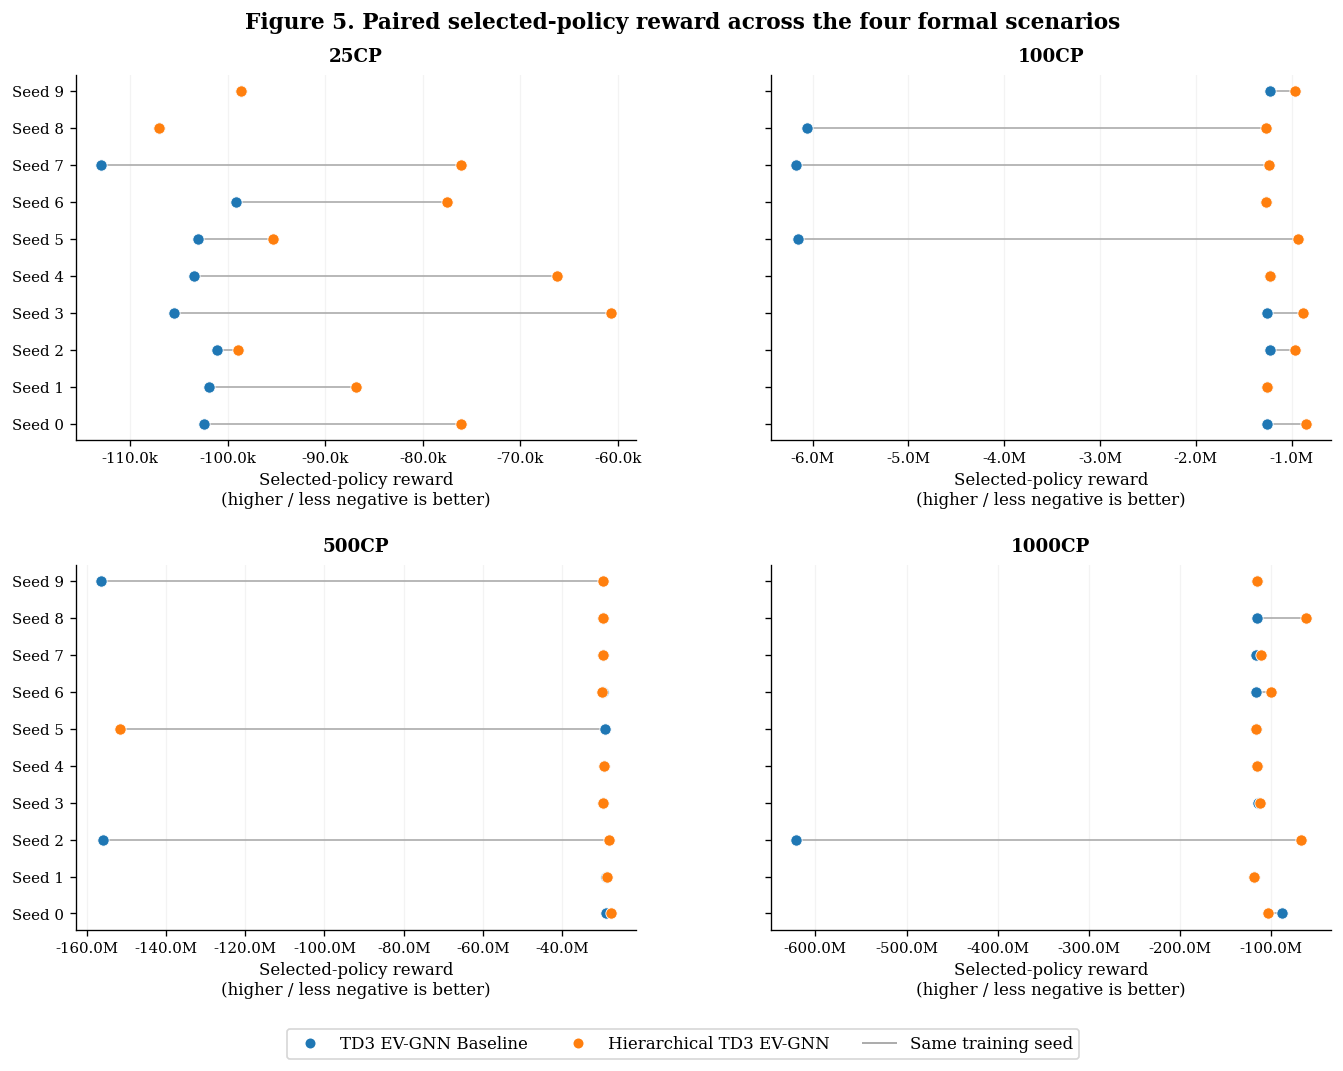

In [17]:
# Figure 5: paired seed comparison using raw selected-policy reward.
fig, axes = plt.subplots(2, 2, figsize=(13.5, 8.8), sharey=True)

for ax, scale in zip(axes.ravel(), SCALE_ORDER):
    seeds, b, h = paired_seed_series(seed_performance, scale, "episode_reward")

    for seed, bv, hv in zip(seeds, b.to_numpy(float), h.to_numpy(float)):
        ax.plot([bv, hv], [seed, seed], color="0.70", linewidth=1.1, zorder=1)
        ax.scatter(
            bv, seed, s=46, color=MODEL_COLOUR[MODEL_ORDER[0]],
            edgecolor="white", linewidth=0.5, zorder=3
        )
        ax.scatter(
            hv, seed, s=46, color=MODEL_COLOUR[MODEL_ORDER[1]],
            edgecolor="white", linewidth=0.5, zorder=3
        )

    ax.set_title(SCALE_LABELS[scale], pad=8)
    ax.set_xlabel("Selected-policy reward\n(higher / less negative is better)")
    ax.xaxis.set_major_formatter(COMPACT_FORMATTER)
    ax.tick_params(axis="x", labelrotation=0, pad=3)
    ax.grid(axis="x", alpha=0.14)

for ax in axes[:, 0]:
    ax.set_yticks(range(10), [f"Seed {i}" for i in range(10)])
for ax in axes[:, 1]:
    ax.tick_params(labelleft=False)

legend = [
    Line2D([0], [0], marker="o", linestyle="", markersize=7,
           markerfacecolor=MODEL_COLOUR[MODEL_ORDER[0]], markeredgecolor="white",
           label="TD3 EV-GNN Baseline"),
    Line2D([0], [0], marker="o", linestyle="", markersize=7,
           markerfacecolor=MODEL_COLOUR[MODEL_ORDER[1]], markeredgecolor="white",
           label="Hierarchical TD3 EV-GNN"),
    Line2D([0], [0], color="0.68", linewidth=1.2, label="Same training seed"),
]
fig.legend(handles=legend, loc="lower center", bbox_to_anchor=(0.5, -0.01),
           ncol=3, frameon=True)
fig.suptitle(
    "Figure 5. Paired selected-policy reward across the four formal scenarios",
    fontsize=13, fontweight="bold", y=0.99
)
fig.subplots_adjust(bottom=0.12, top=0.93, hspace=0.34, wspace=0.24)
plt.show()


In [18]:
# Formal paired statistics for the primary reward family.
def exact_sign_flip_p(diff):
    d = np.asarray(pd.Series(diff).dropna(), dtype=float)
    observed = abs(d.mean())
    signs = np.array(np.meshgrid(*[[-1.0, 1.0]] * len(d))).T.reshape(-1, len(d))
    return float(np.mean(np.abs((signs * d).mean(axis=1)) >= observed - 1e-12))

def holm_adjust(pvalues):
    p = np.asarray(pvalues, dtype=float)
    order = np.argsort(p)
    adjusted = np.empty_like(p)
    running = 0.0
    for rank, idx in enumerate(order):
        running = max(running, (len(p) - rank) * p[idx])
        adjusted[idx] = min(running, 1.0)
    return adjusted

rows = []
for scale in SCALE_ORDER:
    seeds, b, h = paired_seed_series(seed_performance, scale, "episode_reward")
    diff = (h - b).to_numpy(float)
    mean, low, high = mean_ci95(diff)
    rows.append({
        "Scenario": SCALE_LABELS[scale],
        "Mean benefit": mean,
        "CI low": low,
        "CI high": high,
        "Cohen dz": mean / diff.std(ddof=1),
        "Seeds H>B": int((diff > 0).sum()),
        "Paired t": stats.ttest_rel(h, b).pvalue,
        "Wilcoxon": stats.wilcoxon(h, b).pvalue,
        "Sign-flip": exact_sign_flip_p(diff),
    })

reward_stats = pd.DataFrame(rows)
reward_stats["Holm-adjusted t"] = holm_adjust(reward_stats["Paired t"])

evidence_conclusion = {
    "25CP": "Supported reward improvement",
    "100CP": "Strong favourable direction; mean CI includes zero",
    "500CP": "Mixed and heterogeneous",
    "1000CP": "Positive direction; mean CI includes zero",
}

main_table = reward_stats.assign(
    **{
        "Average reward improvement under hierarchy": reward_stats["Mean benefit"].map(reward_text),
        "95% CI of paired improvement": reward_stats.apply(
            lambda r: f"[{reward_text(r['CI low'])}, {reward_text(r['CI high'])}]", axis=1
        ),
        "Seed pairs with higher reward under hierarchy": reward_stats["Seeds H>B"].map(lambda x: f"{int(x)} of 10"),
        "Holm-adjusted p-value": reward_stats["Holm-adjusted t"].map(lambda p: "<0.001" if p < 0.001 else f"{p:.3f}"),
        "Evidence conclusion": reward_stats["Scenario"].map(evidence_conclusion),
    }
)[[
    "Scenario",
    "Average reward improvement under hierarchy",
    "95% CI of paired improvement",
    "Seed pairs with higher reward under hierarchy",
    "Holm-adjusted p-value",
    "Evidence conclusion",
]]

formal_detail = reward_stats.copy()
display(Markdown("**Table 2. Primary paired reward evidence across the four formal scenarios.**"))
display(Markdown(markdown_table(main_table)))


**Table 2. Primary paired reward evidence across the four formal scenarios.**

| Scenario | Average reward improvement under hierarchy | 95% CI of paired improvement | Seed pairs with higher reward under hierarchy | Holm-adjusted p-value | Evidence conclusion |
| --- | --- | --- | --- | --- | --- |
| 25CP | 19.2k | [7.2k, 31.2k] | 9 of 10 | 0.022 | Supported reward improvement |
| 100CP | 1.6M | [-39.3k, 3.3M] | 9 of 10 | 0.164 | Strong favourable direction; mean CI includes zero |
| 500CP | 13.3M | [-37.6M, 64.2M] | 6 of 10 | 0.583 | Mixed and heterogeneous |
| 1000CP | 61.6M | [-62.7M, 185.9M] | 7 of 10 | 0.583 | Positive direction; mean CI includes zero |

## Formal reward interpretation

**25CP.** The hierarchical policy achieved an average paired reward improvement of about **19.2k** relative to the same ten baseline seeds. The 95% confidence interval is approximately **[+7.2k, +31.2k]**, **9 of 10** seed pairs have higher reward under the hierarchy, and the result remains below 0.05 after Holm adjustment across the four reward tests (**adjusted $p=0.022$**). This is the strongest evidence in the study that infrastructure-aligned decision factorisation improves the mean PublicPST reward under the formal protocol.

**100CP.** **9 of 10** seed pairs again favour the hierarchy, but the paired mean confidence interval narrowly crosses zero. The direction is therefore highly consistent across the observed seeds, while the mean effect remains statistically unresolved at the pre-specified family-wise threshold.

**500CP.** Only **6 of 10** seed pairs favour the hierarchy and the paired effects are widely dispersed. The scenario is genuinely heterogeneous rather than a clean win for either architecture.

**1000CP.** **7 of 10** seed pairs favour the hierarchy and the mean effect is positive, but the confidence interval is wide. The data therefore indicate a favourable average direction with substantial seed sensitivity, not the same level of statistical resolution seen at 25CP.

The complete paired t-test, Wilcoxon, exact sign-flip, Cohen $d_z$, and Holm-adjusted results are retained in Appendix B so that the main discussion can focus on effect size, uncertainty, and reproducibility.


### How the paired statistics answer the research question

- **Paired seed comparison (`hierarchy - baseline`)**: each hierarchical policy is compared with the baseline policy carrying the same training-seed label. Positive reward differences mean the hierarchical policy achieved higher / less-negative reward for that pair.
- **95% confidence interval**: summarises uncertainty in the mean paired effect across the ten independently trained seed pairs.
- **Paired t-test**: asks whether the mean within-seed reward difference is distinguishable from zero under the usual paired-sample assumptions.
- **Wilcoxon signed-rank test**: provides a rank-based paired view that is less directly tied to the arithmetic mean.
- **Exact sign-flip test**: with ten pairs, all $2^{10}=1024$ possible sign assignments can be enumerated. This asks how unusual the observed absolute paired mean would be if the signs of the architecture effects were exchangeable.
- **Holm adjustment**: the same reward question is asked at four formal scenarios, so the four paired t-test p-values are adjusted as one family rather than interpreted independently.
- **Paired Cohen $d_z$**: standardises the mean paired difference by the standard deviation of those paired differences.

### Scenario-by-scenario interpretation

| Scenario | Mean reward effect | Paired direction | Holm-adjusted interpretation |
|---|---:|---:|---|
| **25CP** | about **+19.2k** | **9/10** hierarchy-favourable | Mean effect statistically resolved after the four-scale correction |
| **100CP** | about **+1.62M** | **9/10** hierarchy-favourable | Strong directional consistency, but mean effect unresolved |
| **500CP** | about **+13.31M** | **6/10** hierarchy-favourable | Mixed and heterogeneous |
| **1000CP** | about **+61.61M** | **7/10** hierarchy-favourable | Positive mean direction with wide uncertainty |

The important distinction is between **directional consistency** and **statistical resolution of the mean**. For example, 9/10 hierarchy-favourable seeds at 100CP does not imply a 90% deployment success probability, and a wide confidence interval at 1000CP does not imply that the observed positive mean is meaningless. The statistics describe what this set of ten paired training runs can and cannot resolve.


# Decision mechanism: action composition

For every active EV, the selected policy places the action in one of three mutually exclusive regions:

$$
f_0 + f_{\mathrm{interior}} + f_{\max}=1.
$$

Figure 6 replaces the ternary plot with a more direct composition view.

- **Figure 6A** shows the mean action composition across the 10 trained-policy seeds. Every bar totals 100%, so the reader can see how much decision mass lies at zero action, inside the continuous action range, or at the maximum boundary.
- **Figure 6B** shows the 10 seed-level distributions for the two components most relevant to the observed mechanism: maximum-action use and interior-action use.

The purpose is not to claim that interior action is always better. The question is whether the hierarchy changes a strongly boundary-dominated policy into a more graded continuous controller, and whether that change coexists with acceptable tracking and service outcomes.


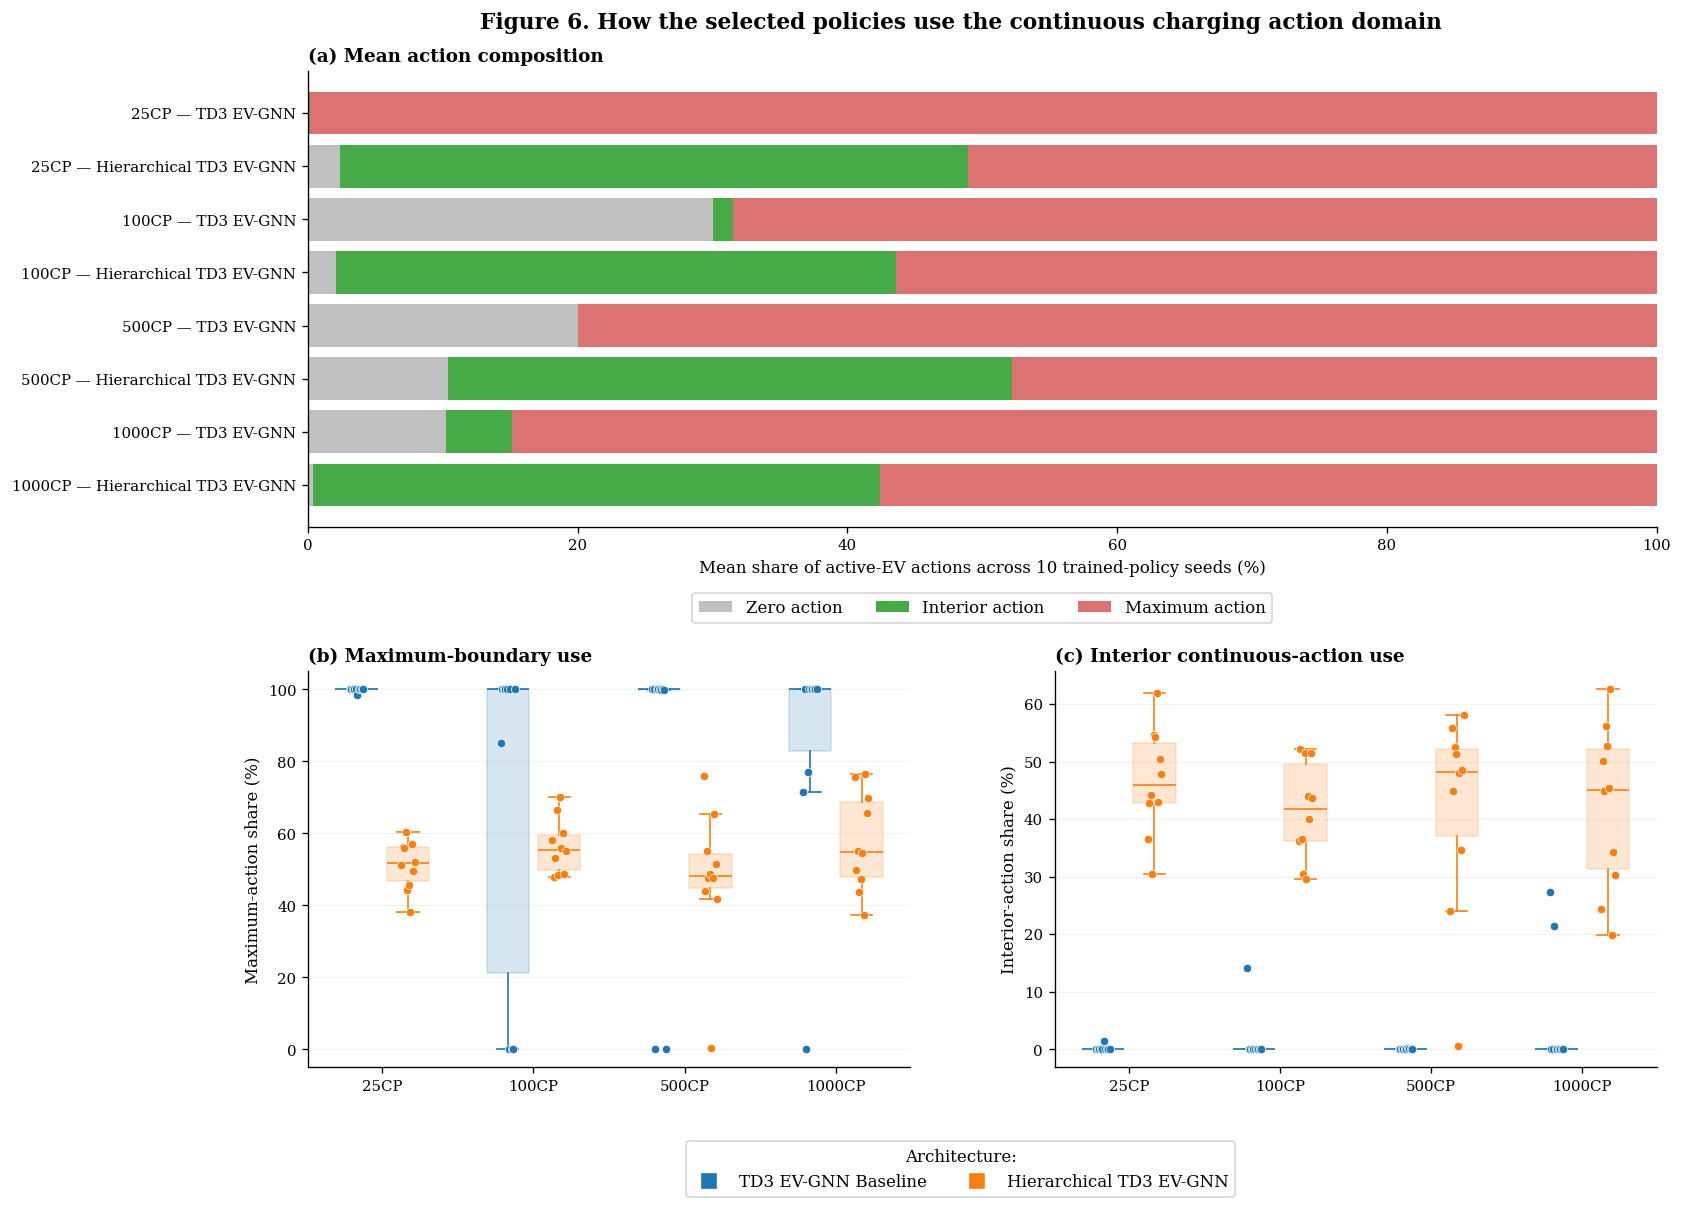

In [28]:
# Figure 6A/B: mean action composition plus seed-level mechanism evidence.
diagnostics = diagnostics.copy()
diagnostics["interior_action_fraction"] = (
    1
    - diagnostics["global_zero_action_fraction_active"]
    - diagnostics["global_action_fraction_at_max_active"]
).clip(0, 1)

component_cols = {
    "Zero action": "#B8B8B8",
    "Interior action": "#2CA02C",
    "Maximum action": "#D95F5F",
}

fig = plt.figure(figsize=(14.5, 10.0))
gs = fig.add_gridspec(2, 2, height_ratios=[1.15, 1.0], hspace=0.34, wspace=0.24)
ax_top = fig.add_subplot(gs[0, :])
ax_max = fig.add_subplot(gs[1, 0])
ax_int = fig.add_subplot(gs[1, 1])

labels, zero_vals, interior_vals, max_vals = [], [], [], []
for scale in SCALE_ORDER:
    for model in MODEL_ORDER:
        d = seed_performance[(seed_performance["scale"] == scale) & (seed_performance["model"] == model)]
        labels.append(f"{SCALE_LABELS[scale]} — {model.replace(' Baseline', '')}")
        zero_vals.append(100 * d["global_zero_action_fraction_active"].mean())
        interior_vals.append(100 * d["interior_action_fraction"].mean())
        max_vals.append(100 * d["global_action_fraction_at_max_active"].mean())

y = np.arange(len(labels))
left = np.zeros(len(labels))
for name, values in [
    ("Zero action", zero_vals),
    ("Interior action", interior_vals),
    ("Maximum action", max_vals),
]:
    ax_top.barh(y, values, left=left, label=name, color=component_cols[name], alpha=0.88)
    left += np.asarray(values)

ax_top.set_yticks(y, labels)
ax_top.set_xlim(0, 100)
ax_top.set_xlabel("Mean share of active-EV actions across 10 trained-policy seeds (%)")
ax_top.set_title("(a) Mean action composition", loc="left", fontweight="semibold")
ax_top.invert_yaxis()
ax_top.legend(loc="lower center", bbox_to_anchor=(0.5, -0.23), ncol=3, frameon=True)

seed_box_points(
    ax_max, None, "global_action_fraction_at_max_active",
    "Maximum-action share (%)", percent=True,
)
seed_box_points(
    ax_int, None, "interior_action_fraction",
    "Interior-action share (%)", percent=True,
)
ax_max.set_title("(b) Maximum-boundary use", loc="left", fontweight="semibold")
ax_int.set_title("(c) Interior continuous-action use", loc="left", fontweight="semibold")

model_handles = [
    Line2D([0], [0], marker="s", linestyle="", markersize=8,
           markerfacecolor=MODEL_COLOUR[m], markeredgecolor=MODEL_COLOUR[m], label=m)
    for m in MODEL_ORDER
]
fig.legend(handles=model_handles, loc="lower center", bbox_to_anchor=(0.5, -0.005),
           ncol=2, frameon=True, title="Architecture:")
fig.suptitle("Figure 6. How the selected policies use the continuous charging action domain",
             fontsize=13, fontweight="bold", y=0.99)
fig.subplots_adjust(bottom=0.11, top=0.94)
plt.show()


## Observed action-composition shift

The hierarchical policy moves away from maximum-boundary dominated control in **all four** formal scenarios. Relative to the paired baseline policies, mean maximum-action use falls by approximately **48.8 percentage points at 25CP, 12.1 at 100CP, 32.2 at 500CP, and 27.3 at 1000CP**.

The destination of that mass is also visible. Interior-action use increases by about **46.4, 40.1, 41.8, and 37.2 percentage points**, respectively. At 25CP, zero-action use increases slightly, whereas at 100CP, 500CP and 1000CP it decreases. The mechanism is therefore not simply “less charging”: the hierarchy generally replaces a substantial part of maximum-boundary behaviour with graded interior actions.

This is one of the clearest architecture-level behavioural differences in the study. It remains a mechanism result rather than a standalone performance claim; Figures 4, 7 and the service outcomes determine whether that behavioural shift is operationally beneficial.

### Reading the action-composition figure in plain language

For an active EV, the charging command can fall into one of three regions:

- **Zero action (grey):** the active EV receives a charging command at the lower boundary.
- **Interior action (green):** the command lies between the lower and upper boundaries—for example 20%, 50%, or 75% of the normalised action range.
- **Maximum action (red):** the command is at the upper action boundary.

A useful intuition is a **dimmer rather than an on/off switch**. Interior actions show that the policy is making greater use of the continuous charging range instead of concentrating most decisions at the two boundaries.

In Figure 6A, the baseline bars are dominated by maximum-boundary action, while the hierarchical bars contain a much larger interior component. Figures 6B and 6C show that this difference is not produced by a single seed: the ten trained-policy means move systematically away from maximum-boundary use and toward interior action under the hierarchy.

This is strong evidence that the decision factorisation changes the **form of the controller's action use**. It does not, by itself, prove smoother physical power at every transformer or guarantee lower overload. Those operational consequences are examined separately.


# Infrastructure allocation mechanism

The hierarchy introduces explicit transformer- and charger-level allocation weights, so the diagnostics also examine **how concentrated positive charging authority is within a scenario**.

For positive allocation shares $s_i$,

$$
HHI=\sum_i s_i^2.
$$

Higher HHI means that positive allocation is more concentrated, lower HHI means it is more distributed. The Gini coefficient describes allocation inequality in a similar descriptive sense. **Neither metric is inherently good or bad.** Concentration can be rational when demand or available capacity is uneven.

Raw HHI is entity-count sensitive, so the main comparison is horizontal: baseline versus hierarchy **within the same formal scenario**. Detailed HHI/Gini episode distributions are retained in Appendix D.

In [20]:
# Main-text HHI summary: architecture comparison within each formal scenario.
rows = []
for scale in SCALE_ORDER:
    row = {"Scenario": SCALE_LABELS[scale]}
    for metric, level in [
        ("transformer_positive_charge_action_hhi_mean", "Transformer"),
        ("charger_positive_charge_action_hhi_mean", "Charger"),
    ]:
        b = seed_performance[(seed_performance["scale"] == scale) & (seed_performance["model"] == MODEL_ORDER[0])][metric].mean()
        h = seed_performance[(seed_performance["scale"] == scale) & (seed_performance["model"] == MODEL_ORDER[1])][metric].mean()
        row[f"TD3 EV-GNN {level.lower()} HHI"] = f"{b:.3f}"
        row[f"Hierarchical TD3 EV-GNN {level.lower()} HHI"] = f"{h:.3f}"
        row[f"Change under hierarchy ({level.lower()} HHI)"] = f"{h-b:+.3f}"
    rows.append(row)

display(Markdown("**Positive-charge allocation concentration (seed-level means; compare architectures within each scenario):**"))
display(Markdown(markdown_table(pd.DataFrame(rows))))


**Positive-charge allocation concentration (seed-level means; compare architectures within each scenario):**

| Scenario | TD3 EV-GNN transformer HHI | Hierarchical TD3 EV-GNN transformer HHI | Change under hierarchy (transformer HHI) | TD3 EV-GNN charger HHI | Hierarchical TD3 EV-GNN charger HHI | Change under hierarchy (charger HHI) |
| --- | --- | --- | --- | --- | --- | --- |
| 25CP | 0.387 | 0.421 | +0.033 | 0.115 | 0.149 | +0.034 |
| 100CP | 0.175 | 0.195 | +0.020 | 0.046 | 0.063 | +0.017 |
| 500CP | 0.146 | 0.125 | -0.021 | 0.088 | 0.093 | +0.005 |
| 1000CP | 0.021 | 0.021 | +0.000 | 0.007 | 0.007 | +0.000 |

## Observed allocation pattern

Within **25CP**, the hierarchical actor is more concentrated at both infrastructure levels: transformer HHI rises from about **0.387 to 0.421** and charger HHI from **0.115 to 0.149**. The same direction appears at **100CP** (transformer **0.175 → 0.195**, charger **0.046 → 0.063**).

At **500CP**, the mechanism is mixed: transformer allocation becomes less concentrated (**0.146 → 0.125**), while charger HHI changes only slightly upward (**0.088 → 0.093**). At **1000CP**, the mean HHI values are effectively unchanged at the reported precision.

These results do not establish that more concentrated or more distributed allocation is preferable. They show that the hierarchical architecture changes **where decision authority is concentrated**, and that this change itself is scale-dependent.

### HHI in plain language

The Herfindahl-Hirschman Index (HHI) answers a simple question: **is positive charging action concentrated in a small number of infrastructure groups, or spread across many groups?**

- **Higher HHI** means a larger share of positive charging action is concentrated in fewer transformers or chargers.
- **Lower HHI** means that positive charging action is more distributed across the groups available in that scenario.
- **Transformer HHI** describes concentration across transformer groups.
- **Charger HHI** describes concentration across charger groups.

The metric is descriptive. Concentration can be sensible when demand, availability, or network state is uneven, and a lower value is not automatically better.

### What changes across the four formal scenarios

- **25CP:** transformer HHI increases from about **0.387 to 0.421**, and charger HHI from **0.115 to 0.149**.
- **100CP:** transformer HHI increases from about **0.175 to 0.195**, and charger HHI from **0.046 to 0.063**.
- **500CP:** transformer HHI decreases from about **0.146 to 0.125**, while charger HHI changes only slightly upward.
- **1000CP:** the architecture means are very close at the reported precision.

The important result is therefore not that the hierarchy "always concentrates" or "always spreads" charging action. It changes where positive action is concentrated, and the direction of that change depends on infrastructure level and formal scenario. The diagnostic data do not establish why a particular concentration pattern occurred, so HHI should be interpreted alongside overload and service outcomes rather than as a utility score.


# Operational trade-offs

A higher PublicPST reward does not automatically imply lower infrastructure stress. Figure 7 therefore compares the two architectures **within the same paired training seed**.

For power-tracker violation $V$ and transformer overload $O$,

$$
\Delta_{\mathrm{tracking}}
=
V^{\mathrm{TD3\ EV-GNN}}
-
V^{\mathrm{hierarchical}},
$$

$$
\Delta_{\mathrm{overload}}
=
O^{\mathrm{TD3\ EV-GNN}}
-
O^{\mathrm{hierarchical}}.
$$

Each point in Figure 7 is one paired training-seed mean:

- $x>0$: the hierarchical policy has **fewer PublicPST power-tracker violations**;
- $x<0$: the TD3 EV-GNN baseline tracks better;
- $y>0$: the hierarchical policy has **lower transformer overload**;
- $y<0$: the TD3 EV-GNN baseline has lower overload.

Thus the upper-right quadrant is the clearest operational win for the hierarchy: better tracking **and** lower transformer stress. The lower-right quadrant means better tracking but higher overload. The four scenarios are shown as large 2×2 panels so the ten paired seeds remain readable.


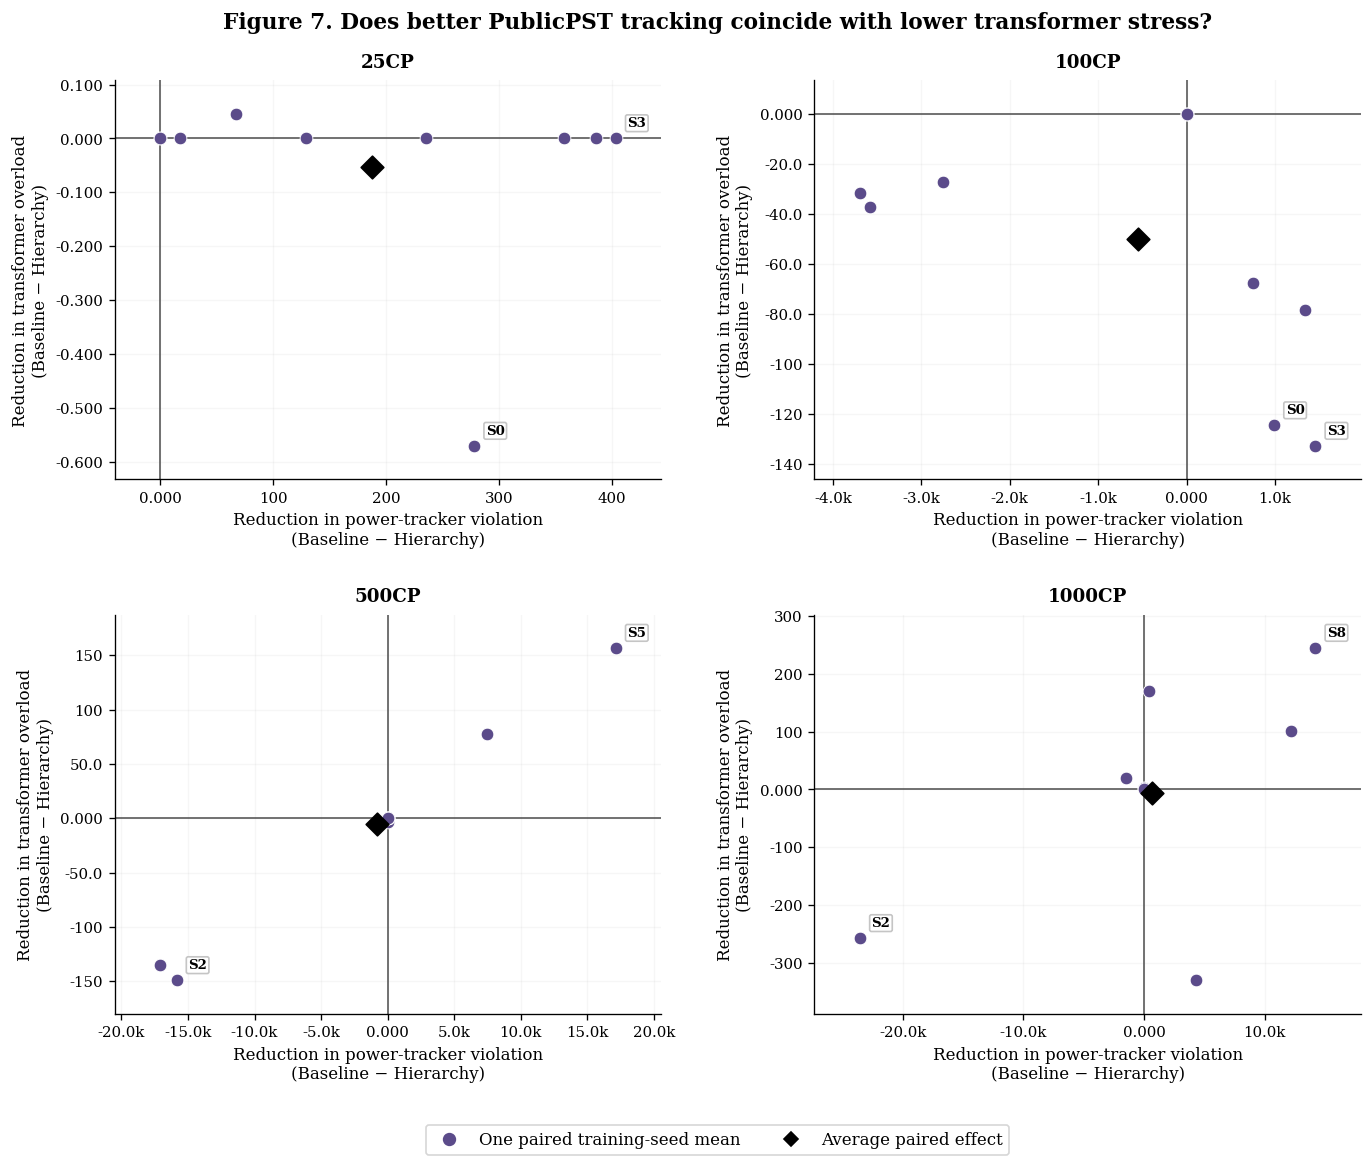

**EV-service changes accompanying the control result:**

| Scenario | Mean change in user satisfaction under hierarchy | Seed pairs with higher satisfaction under hierarchy | Mean change in total energy delivered under hierarchy | Seed pairs with more energy delivered under hierarchy |
| --- | --- | --- | --- | --- |
| 25CP | -0.19 percentage points | 0 of 10 | -24.6 | 1 of 10 |
| 100CP | +6.55 percentage points | 3 of 10 | 1.4k | 3 of 10 |
| 500CP | +2.05 percentage points | 2 of 10 | 2.2k | 3 of 10 |
| 1000CP | +1.94 percentage points | 2 of 10 | 4.1k | 2 of 10 |

In [21]:
# Figure 7: seed-level tracking–infrastructure trade-off.
fig, axes = plt.subplots(2, 2, figsize=(13.4, 9.6))

for ax, scale in zip(axes.ravel(), SCALE_ORDER):
    d = paired[paired["scale"] == scale].sort_values("training_seed")
    x = d["power_violation_reduction"].to_numpy(float)
    y = d["overload_reduction"].to_numpy(float)

    ax.axvline(0, color="0.35", linewidth=1.0)
    ax.axhline(0, color="0.35", linewidth=1.0)
    ax.scatter(x, y, s=58, color="#5B4B8A", edgecolor="white", linewidth=0.55, zorder=3)

    # Label only the most influential seed-level points to keep the plot readable.
    influence = np.abs((x - x.mean()) / (np.std(x) + 1e-12)) + np.abs((y - y.mean()) / (np.std(y) + 1e-12))
    notable = set(np.argsort(influence)[-2:])

    for idx, (seed, xv, yv) in enumerate(zip(d["training_seed"], x, y)):
        if idx in notable:
            ax.annotate(
                f"S{int(seed)}", (xv, yv), xytext=(7, 7), textcoords="offset points",
                fontsize=8, fontweight="semibold",
                bbox=dict(boxstyle="round,pad=0.14", fc="white", ec="0.75", alpha=0.9)
            )

    ax.scatter(x.mean(), y.mean(), s=92, marker="D", color="black", zorder=4)
    ax.set_xlim(*paired_difference_limits(x, [0]))
    ax.set_ylim(*paired_difference_limits(y, [0]))
    ax.xaxis.set_major_formatter(COMPACT_FORMATTER)
    ax.yaxis.set_major_formatter(COMPACT_FORMATTER)
    ax.set_title(SCALE_LABELS[scale], pad=8)
    ax.set_xlabel("Reduction in power-tracker violation\n(Baseline − Hierarchy)")
    ax.set_ylabel("Reduction in transformer overload\n(Baseline − Hierarchy)")
    ax.grid(alpha=0.10)

handles = [
    Line2D([0], [0], marker="o", linestyle="", markersize=7, color="#5B4B8A",
           label="One paired training-seed mean"),
    Line2D([0], [0], marker="D", linestyle="", markersize=6, color="black",
           label="Average paired effect"),
]
fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.01),
           ncol=2, frameon=True)
fig.suptitle(
    "Figure 7. Does better PublicPST tracking coincide with lower transformer stress?",
    fontsize=13, fontweight="bold", y=0.99
)
fig.subplots_adjust(bottom=0.12, top=0.93, hspace=0.34, wspace=0.28)
plt.show()

service_rows = []
for scale in SCALE_ORDER:
    d = paired[paired["scale"] == scale]
    service_rows.append({
        "Scenario": SCALE_LABELS[scale],
        "Mean change in user satisfaction under hierarchy": f"{d['satisfaction_change_pp'].mean():+.2f} percentage points",
        "Seed pairs with higher satisfaction under hierarchy": f"{int((d['satisfaction_change_pp'] > 0).sum())} of 10",
        "Mean change in total energy delivered under hierarchy": compact_number(d["energy_delivered_change"].mean()),
        "Seed pairs with more energy delivered under hierarchy": f"{int((d['energy_delivered_change'] > 0).sum())} of 10",
    })

display(Markdown("**EV-service changes accompanying the control result:**"))
display(Markdown(markdown_table(pd.DataFrame(service_rows))))


### Plain-language interpretation of the tracking–infrastructure trade-off

Figure 7 asks whether better PublicPST tracking and lower transformer overload occur together for the **same trained seed**.

If a point moves to the right, the hierarchical policy has fewer power-tracker violations for that seed. If it moves upward, it has lower transformer overload. The most favourable quadrant is therefore the upper-right, where both quantities improve together.

The key result is that the two objectives do not always move in the same direction. A hierarchy-favourable tracking effect can coexist with an adverse overload effect, and the mean can be strongly influenced by a small number of large seed-level differences. This is why reward, tracking, and transformer stress must be read as separate pieces of evidence rather than collapsed into a single "better or worse" judgement.


## Observed tracking–infrastructure trade-off

The trade-off is clearly scale-dependent.

- **25CP:** mean tracking improves, but mean transformer overload increases. The control gain therefore comes with a measurable infrastructure cost in this scenario.
- **100CP:** the mean violation and overload differences both favour the baseline, even though several individual seeds improve tracking under the hierarchy. A small number of adverse seeds materially affect the mean.
- **500CP:** the seed cloud spans both sides of the tracking and overload axes. This is a genuinely mixed scenario rather than a clean operational win for either architecture.
- **1000CP:** mean power-tracker violation is slightly lower under the hierarchy, while mean overload is slightly higher. Importantly, **7/10** seeds actually show lower overload under the hierarchy, so the negative mean is driven by a minority of large adverse overload differences.

The EV-service table exposes the same mean-versus-consistency issue. Mean satisfaction is positive at 100CP, 500CP and 1000CP, but only **3/10, 2/10 and 2/10** paired seeds favour the hierarchy, respectively. These means are therefore not evidence of a broadly shared service improvement.

### How to read Figure 7

```text
                    ▲ Lower transformer overload (y > 0)
                    │
   Baseline tracks  │   Upper-right:
   better, but      │   Hierarchy has fewer
   hierarchy has    │   tracking violations
   lower overload   │   AND lower overload
 ◄──────────────────┼──────────────────► Fewer power-tracker
 (x < 0)            │                    violations under hierarchy
                    │   Lower-right:
                    │   better tracking,
                    │   higher overload
                    ▼ (y < 0)
```

Each purple point is one paired training seed and the black diamond is the mean paired effect across the ten seeds.

- **25CP:** tracking generally moves in the hierarchy-favourable direction, while transformer overload often moves in the opposite direction.
- **100CP:** the seed cloud is more polarised; several seeds improve tracking while overload worsens, and several seeds move in the opposite tracking direction.
- **500CP:** the paired effects occupy multiple quadrants, so no single operational direction represents the scenario well.
- **1000CP:** **7/10** seeds have lower overload under the hierarchy and the control metrics are often hierarchy-favourable, but a minority of large adverse overload effects pull the mean toward the baseline.

The EV-service table adds another dimension. Mean satisfaction can be slightly positive even when most seed pairs do not improve, because a small number of larger positive changes can raise the arithmetic mean. The practical lesson is not that one objective should automatically dominate another; it is that PublicPST control, transformer stress, and EV service remain distinct design objectives that can trade off against one another.


# Seed-direction consistency across outcomes

Effect magnitude and directional consistency answer different questions. Figure 8 deliberately ignores magnitude and asks only:

> **How often does the architecture effect repeat in the same direction across the 10 independently trained seed pairs?**

Each horizontal bar totals ten seeds. The **orange segment** counts seed pairs in which the hierarchical architecture is favourable for that outcome; the **blue segment** counts seed pairs in which the TD3 EV-GNN baseline is favourable; grey would indicate exact ties.

This is a reproducibility view, not an effect-size plot. A 9/10 bar means that nine independently trained seed pairs move in the hierarchy-favourable direction; it does not mean that the nine effects have equal magnitude.

Grey indicates an **exact tie** in the seed-level metric estimate; it does not indicate missing data.


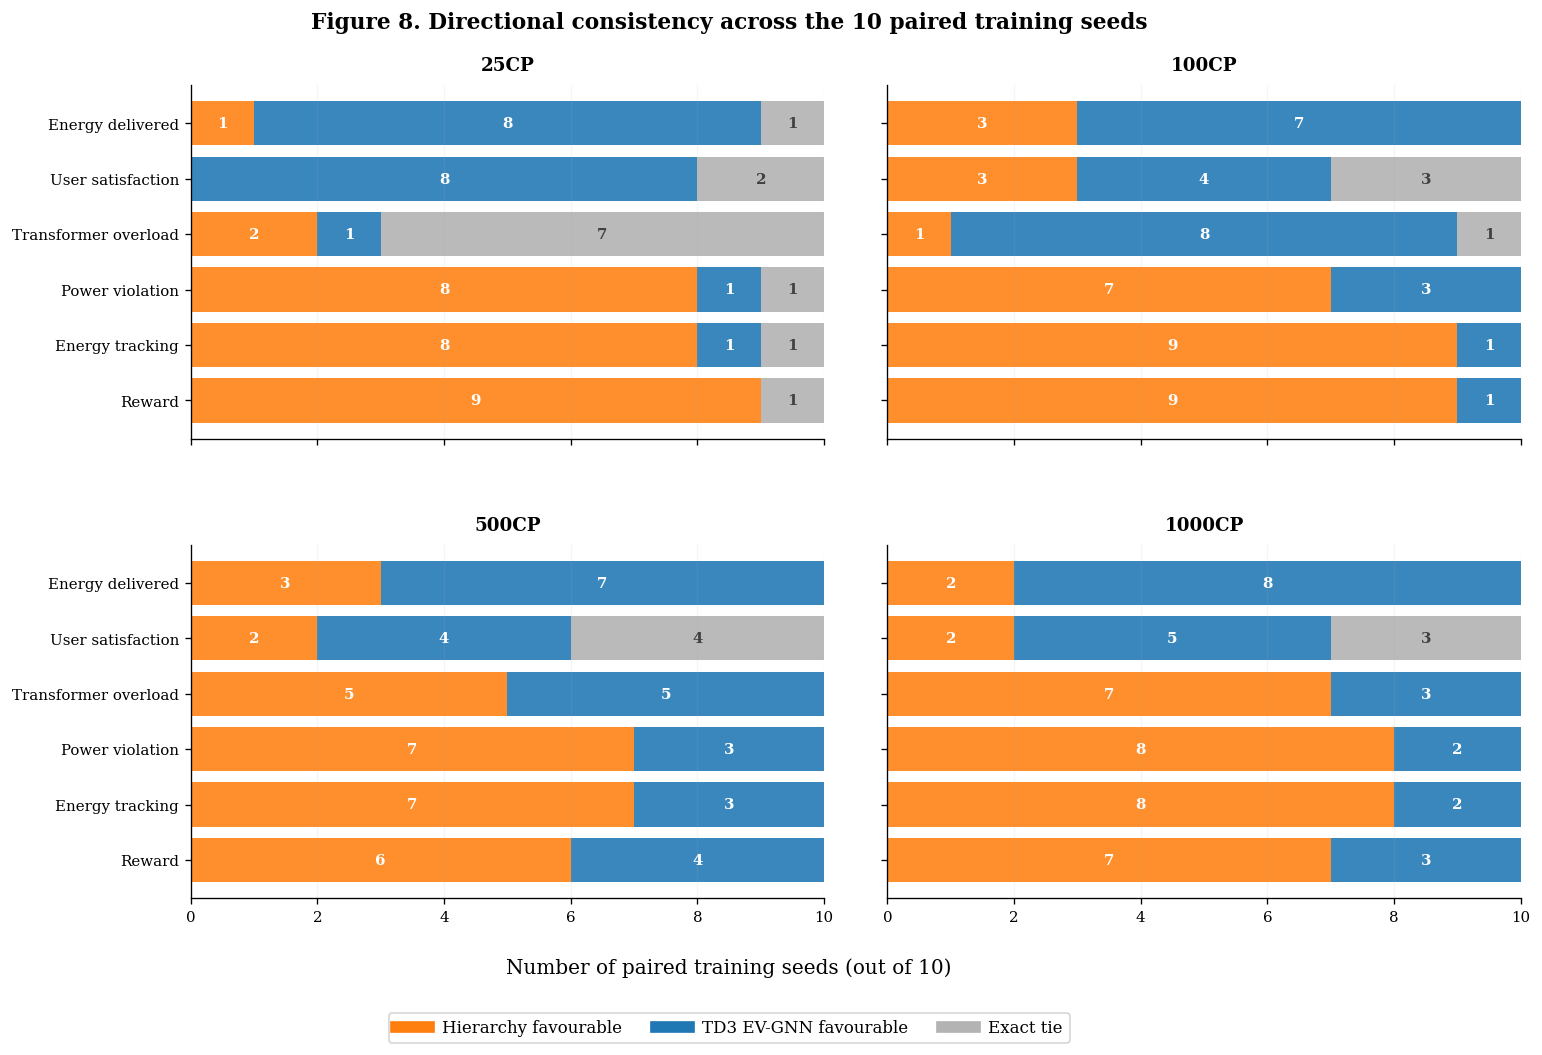

In [22]:
# Figure 8: directional consistency across paired training seeds.
direction_metrics = [
    ("Reward", "reward_benefit"),
    ("Energy tracking", "energy_tracking_reduction"),
    ("Power violation", "power_violation_reduction"),
    ("Transformer overload", "overload_reduction"),
    ("User satisfaction", "satisfaction_change_pp"),
    ("Energy delivered", "energy_delivered_change"),
]

fig, axes = plt.subplots(2, 2, figsize=(13.6, 8.8), sharex=True, sharey=True)

for panel, (ax, scale) in enumerate(zip(axes.ravel(), SCALE_ORDER)):
    d = paired[paired["scale"] == scale]
    labels = [label for label, _ in direction_metrics]
    y = np.arange(len(labels))
    h_counts, b_counts, ties = [], [], []

    for _, metric in direction_metrics:
        values = d[metric].to_numpy(float)
        h_counts.append(int((values > 0).sum()))
        b_counts.append(int((values < 0).sum()))
        ties.append(int((values == 0).sum()))

    h_counts = np.asarray(h_counts)
    b_counts = np.asarray(b_counts)
    ties = np.asarray(ties)

    ax.barh(y, h_counts, color=MODEL_COLOUR[MODEL_ORDER[1]], alpha=0.88)
    ax.barh(y, b_counts, left=h_counts, color=MODEL_COLOUR[MODEL_ORDER[0]], alpha=0.88)
    if ties.any():
        ax.barh(y, ties, left=h_counts + b_counts, color="0.70", alpha=0.9)

    for yi, hc, bc, tc in zip(y, h_counts, b_counts, ties):
        if hc > 0:
            ax.text(hc / 2, yi, str(hc), ha="center", va="center",
                    color="white", fontsize=9, fontweight="semibold")
        if bc > 0:
            ax.text(hc + bc / 2, yi, str(bc), ha="center", va="center",
                    color="white", fontsize=9, fontweight="semibold")
        if tc > 0:
            ax.text(hc + bc + tc / 2, yi, str(tc), ha="center", va="center",
                    color="0.25", fontsize=9, fontweight="semibold")

    ax.set_xlim(0, 10)
    ax.set_xticks(range(0, 11, 2))
    ax.set_title(SCALE_LABELS[scale], pad=9)
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.12)

    if panel % 2 == 0:
        ax.set_yticks(y, labels)
    else:
        ax.tick_params(labelleft=False)

fig.supxlabel("Number of paired training seeds (out of 10)", y=0.075)

legend = [
    Line2D([0], [0], color=MODEL_COLOUR[MODEL_ORDER[1]], lw=7, label="Hierarchy favourable"),
    Line2D([0], [0], color=MODEL_COLOUR[MODEL_ORDER[0]], lw=7, label="TD3 EV-GNN favourable"),
    Line2D([0], [0], color="0.70", lw=7, label="Exact tie"),
]
fig.legend(handles=legend, loc="lower center", bbox_to_anchor=(0.5, 0.005),
           ncol=3, frameon=True)
fig.suptitle(
    "Figure 8. Directional consistency across the 10 paired training seeds",
    fontsize=13, fontweight="bold", y=0.99
)
fig.subplots_adjust(left=0.17, right=0.985, bottom=0.15, top=0.92, hspace=0.30, wspace=0.10)
plt.show()


## Reading Figure 8: directional consistency across trained seeds

At **25CP**, the control improvement is highly reproducible: reward, energy tracking, and power-tracker violation favour the hierarchy in **9/10, 8/10, and 8/10** paired seeds. That consistency does not extend to infrastructure or user service: only **2/10** seeds show lower overload and **0/10** show higher user satisfaction. The 25CP result is therefore a strong control gain with a clear operational trade-off.

At **100CP**, reward and energy tracking favour the hierarchy in **9/10** seeds, so the control direction is common even though the mean reward confidence interval includes zero. Transformer overload favours the hierarchy in only **1/10** seeds. The architecture therefore frequently improves the control objective without providing the same infrastructure benefit.

The **500CP** scenario is genuinely mixed: reward favours the hierarchy in **6/10** seeds, tracking measures in **7/10**, overload in **5/10**, and satisfaction in only **2/10**. No single directional claim represents this scenario well.

At **1000CP**, reward, energy tracking, power-tracker violation, and overload favour the hierarchy in **7/10, 8/10, 8/10, and 7/10** seeds, respectively. User satisfaction favours the hierarchy in only **2/10** seeds. This is a useful example of why mean effects and seed consistency must be read together: a positive mean satisfaction change can coexist with a majority of paired seeds moving in the opposite direction.


# Cross-scale synthesis and research findings

The four scenarios are progressively larger **configured PublicPST environments**, not a single-factor experiment in charging-point count. The synthesis therefore asks where the hierarchy is favourable, where evidence remains uncertain, and what operational trade-offs accompany the control result.

The table keeps checkpoint timing separate from robustness. A later best checkpoint only means that the best scheduled evaluation occurred later; it does not by itself prove more stable or better optimisation.

In [23]:
# Table 3: compact research synthesis across the four formal scenarios.
overall_reading = {
    "25cp": "Supported control gain with a clear graded-action mechanism; infrastructure and service trade-offs remain.",
    "100cp": "Strong control direction but unresolved mean reward effect; overload is mostly baseline-favourable.",
    "500cp": "Mixed efficacy and infrastructure evidence despite a clear shift toward graded interior actions.",
    "1000cp": "Control and overload directions are often hierarchy-favourable, but uncertainty and service inconsistency remain.",
}

rows = []
for scale in SCALE_ORDER:
    d = paired[paired["scale"] == scale]
    stat = reward_stats[reward_stats["Scenario"] == SCALE_LABELS[scale]].iloc[0]
    rows.append({
        "Scenario": SCALE_LABELS[scale],
        "Control evidence": (
            f"Reward {reward_text(stat['Mean benefit'])}; "
            f"95% CI [{reward_text(stat['CI low'])}, {reward_text(stat['CI high'])}]; "
            f"{int(stat['Seeds H>B'])}/10 seeds"
        ),
        "Decision mechanism": (
            f"Maximum-action share {-d['max_action_reduction_pp'].mean():+.1f} pp; "
            f"interior-action share {d['interior_action_change_pp'].mean():+.1f} pp"
        ),
        "Infrastructure evidence": (
            f"Lower overload in {int((d['overload_reduction'] > 0).sum())}/10 paired seeds"
        ),
        "EV-service evidence": (
            f"Higher satisfaction in {int((d['satisfaction_change_pp'] > 0).sum())}/10 paired seeds"
        ),
        "Overall conclusion": overall_reading[scale],
    })

display(Markdown("**Table 3. Cross-scale research synthesis.**"))
display(Markdown(markdown_table(pd.DataFrame(rows))))


**Table 3. Cross-scale research synthesis.**

| Scenario | Control evidence | Decision mechanism | Infrastructure evidence | EV-service evidence | Overall conclusion |
| --- | --- | --- | --- | --- | --- |
| 25CP | Reward 19.2k; 95% CI [7.2k, 31.2k]; 9/10 seeds | Maximum-action share -48.8 pp; interior-action share +46.4 pp | Lower overload in 2/10 paired seeds | Higher satisfaction in 0/10 paired seeds | Supported control gain with a clear graded-action mechanism; infrastructure and service trade-offs remain. |
| 100CP | Reward 1.6M; 95% CI [-39.3k, 3.3M]; 9/10 seeds | Maximum-action share -12.1 pp; interior-action share +40.1 pp | Lower overload in 1/10 paired seeds | Higher satisfaction in 3/10 paired seeds | Strong control direction but unresolved mean reward effect; overload is mostly baseline-favourable. |
| 500CP | Reward 13.3M; 95% CI [-37.6M, 64.2M]; 6/10 seeds | Maximum-action share -32.2 pp; interior-action share +41.8 pp | Lower overload in 5/10 paired seeds | Higher satisfaction in 2/10 paired seeds | Mixed efficacy and infrastructure evidence despite a clear shift toward graded interior actions. |
| 1000CP | Reward 61.6M; 95% CI [-62.7M, 185.9M]; 7/10 seeds | Maximum-action share -27.3 pp; interior-action share +37.2 pp | Lower overload in 7/10 paired seeds | Higher satisfaction in 2/10 paired seeds | Control and overload directions are often hierarchy-favourable, but uncertainty and service inconsistency remain. |

## Results and interpretation

### Primary architecture-level change: more graded use of the continuous action range

The most reproducible architecture-level result is the action mechanism. Across **all four** formal PublicPST scenarios, the Hierarchical TD3 EV-GNN substantially reduces maximum-boundary charging and shifts decisions into the interior of the continuous action range. Mean maximum-action use falls by approximately **48.8, 12.1, 32.2, and 27.3 percentage points** from 25CP to 1000CP, while interior-action use increases by approximately **46.4, 40.1, 41.8, and 37.2 percentage points**.

This is stronger than saying that the architecture merely "changes behaviour". Because TD3, the graph state, reward family, PublicPST environment, and charging-only $[0,1]$ action interface are held fixed, the persistent action-composition difference is attributable to the change in **decision formation** rather than to a different reinforcement-learning algorithm or action domain.

### Control efficacy across the formal scenarios

At **25CP**, the behavioural change coincides with the strongest control-efficacy result: mean selected-policy reward improves by about **19.2k**, the 95% paired confidence interval is approximately **[+7.2k,+31.2k]**, **9/10** seeds favour the hierarchy, and the reward result remains statistically resolved after Holm adjustment (**adjusted $p=0.022$**). Mean power-tracker violation also falls from approximately **785.8 to 598.5**.

At **100CP, 500CP, and 1000CP**, the mean reward direction remains hierarchy-favourable, but the uncertainty is substantially larger. Reward favours the hierarchy in **9/10**, **6/10**, and **7/10** paired seeds, respectively, while the paired mean confidence intervals include zero. These scenarios therefore provide favourable but less statistically resolved control evidence rather than the same confirmatory mean-effect result observed at 25CP.

### Why the trade-offs matter

The hierarchy does **not** provide a universal operational win in its present form. Transformer overload is not consistently lower, and user-satisfaction means can disagree with the majority seed direction. Improved fleet-level tracking therefore cannot be treated as equivalent to improved infrastructure operation or improved user service.

The research value is that explicit infrastructure-aligned decision factorisation produces a repeatable and interpretable change in controller behaviour, demonstrates that this change can materially improve PublicPST control, and exposes the remaining allocation trade-offs in a form that can be investigated by controlled architectural ablation.


# Practical interpretation

**Charging Point Operator.** The hierarchical architecture can deliver a materially better PublicPST response, with the clearest statistically supported improvement at 25CP and favourable reward directions at the larger formal scenarios. Its most consistent behavioural characteristic is that it relies much less on maximum-boundary EV commands and makes substantially greater use of the continuous interior of the action range. For a CPO, that means the controller is using a more graded decision mechanism rather than concentrating most active-EV commands at the upper boundary.

**Distribution infrastructure.** The same control improvement does not automatically reduce transformer stress. The overload results are scale- and seed-dependent, and some scenarios contain important adverse cases. The present hierarchy should therefore be interpreted as changing **how charging authority is formed**, not as having already solved infrastructure-aware allocation.

**EV users.** Better CPO tracking also does not guarantee better user service. Satisfaction is not consistently hierarchy-favourable across independently trained seeds. This separates the system-level control objective from the user-service objective and identifies a second design dimension that later reward or allocation refinements may need to address.

**Research value relative to the baseline.** The TD3 EV-GNN baseline already represents the physical network with a graph, but it forms final EV actions directly. The hierarchical architecture uses the same topology to structure **decision authority** through transformer allocation, charger allocation, and EV gating. The 75k evidence shows that this is not a cosmetic architectural change: it consistently alters action-space use and can produce substantial control gains. It also creates decision layers that can be observed and ablated, making layer-wise architectural attribution possible.


# Conclusion

## What did the study demonstrate?

The 75,000-step Formal PublicPST experiment shows that explicitly aligning TD3 EV-GNN **decision formation** with the CPO–Transformer–Charger–EV hierarchy materially changes controller behaviour relative to direct EV-node action formation. The clearest and most reproducible effect is mechanistic: across all four formal scenarios, the hierarchical actor substantially reduces upper-bound action saturation and shifts control toward graded interior actions.

Because the two architectures share TD3, graph-structured state, the PublicPST environment, reward family, and charging-only action domain, this persistent behavioural difference can be attributed to the way the final decision is structured.

## Where did the hierarchy outperform the baseline?

The strongest statistically resolved reward result occurs at **25CP**. Selected-policy reward improves from approximately **−103.5k to −84.3k**, the paired mean improvement is about **+19.2k**, **9/10** seed pairs favour the hierarchy, and the four-scale Holm-adjusted reward result remains below 0.05 (**$p=0.022$**).

At **100CP, 500CP, and 1000CP**, the mean selected-policy reward also favours the hierarchy, but seed-level uncertainty is much larger. The directions are common at 100CP (**9/10**) and still favourable in a majority of seeds at 1000CP (**7/10**), while 500CP is genuinely mixed (**6/10**). These results support favourable larger-scenario directions without establishing the same statistically resolved mean effect as 25CP.

## Why is the architecture scientifically useful?

The baseline uses the physical topology to construct graph representations but forms final EV charging actions directly. The hierarchical policy turns that same topology into an explicit decision structure:

```text
graph / CPO scale
        ↓
transformer allocation
        ↓
charger allocation
        ↓
EV-specific gate
        ↓
EV charging action
```

The four-scale evidence shows that this structural intervention consistently changes how the continuous action space is used and can translate that change into better PublicPST control. The explicit transformer, charger, and EV decision levels also create a natural route for later ablation: individual decision layers can be removed to determine which parts of the hierarchy are necessary for the observed mechanism.

## What remains unresolved?

The current full hierarchy does not provide uniformly favourable operational outcomes. Transformer overload is not consistently improved, EV-user satisfaction is not consistently hierarchy-favourable, and the 500CP/1000CP results show substantial seed sensitivity. Mean and majority-seed directions can disagree, demonstrating that a small number of large outcomes can materially affect an average.

The evidence therefore supports the hierarchical architecture as a meaningful control intervention, while also showing that infrastructure stress and user service remain separate design objectives rather than consequences that are automatically solved by better PublicPST tracking.

## What follows logically?

The next architecture-attribution experiment removes charger-level decision allocation while retaining transformer-level hierarchical decision formation. That comparison asks whether the charger layer is necessary for the observed graded-action mechanism and control benefit, or whether it mainly changes optimisation and operational trade-offs.


# Claim boundaries and next architecture-attribution question

The present conclusions apply to the four formal PublicPST configurations analysed here. They do not establish unseen-topology generalisation, unseen-demand generalisation, V2G performance, or superiority across reinforcement-learning algorithms.

## Immediate architecture-attribution question

The next comparison removes charger-level decision allocation while retaining transformer-level hierarchy:

```text
Full hierarchy
CPO / graph scale
→ Transformer allocation
→ Charger allocation
→ EV gate
→ EV action

Charger-level allocation removed
CPO / graph scale
→ Transformer allocation
→ EV decision
```

The research question is:

> **Does explicit charger-level allocation provide additional control value beyond transformer-level hierarchical decision formation, or is the principal behavioural effect already produced at the transformer level?**

The comparison should retain the same four formal scenarios, ten paired training seeds, 75,000-step budget, selected `model.best` final evaluation, and infrastructure diagnostics. The most informative outcomes are:

1. **Reward and tracking:** does the control benefit remain after removing the charger layer?
2. **Maximum/interior action behaviour:** is the shift away from maximum-boundary charging a general hierarchy effect or specifically a charger-layer effect?
3. **Transformer overload:** does the infrastructure trade-off change?
4. **EV service:** do satisfaction and delivered-energy outcomes become more or less consistent?
5. **Seed variability:** do the large 500CP/1000CP differences become more or less severe?
6. **Selected-checkpoint timing:** does the reduced architecture locate its best deterministic policy at a different part of the training budget?

### Competing explanations

**H1 — Charger-level allocation contributes genuine additional value.** If removing it materially weakens reward/tracking or restores maximum-boundary saturation, the charger layer is part of the observed control mechanism.

**H2 — Charger-level allocation introduces unnecessary constraint or optimisation difficulty.** If the reduced hierarchy preserves the main control mechanism while reducing important failure modes or trade-offs, the charger layer may be over-constraining in that configuration.

**H3 — Transformer-level hierarchy is the principal contributor.** If the reduced and full hierarchies remain similar in the core action mechanism, the architectural claim should be narrowed to transformer-level hierarchical decision formation rather than assuming the full transformer–charger–EV factorisation is necessary.

These are competing interpretations to be tested by the next controlled ablation; they are not conclusions of the present notebook.


# Appendix A - Metric glossary

| Metric | What it measures | Better direction | Operational meaning | Main caution |
|---|---|---|---|---|
| Episode reward | PublicPST objective outcome | Higher / less negative | Overall control efficacy under the simulator reward | Composite task objective; inspect underlying tracking/service metrics |
| Tracking error | Aggregate setpoint mismatch | Lower | Requested and realised charging power are closer | Exact simulator definition should be retained |
| Energy-tracking error | Accumulated energy mismatch | Lower | Better cumulative energy alignment | Distinct from instantaneous power violation |
| Power-tracker violation | Violation burden around the requested trajectory | Lower | More reliable adherence to the permitted tracking region | Must be interpreted with the configured tolerance |
| Zero-action fraction | Active-EV decisions at the lower boundary | Contextual | How often active EVs receive no charging command | High can be appropriate or pathological |
| Maximum-action fraction | Active-EV decisions at the upper boundary | Contextual | Degree of upper-bound saturation | Lower is not automatically better |
| Interior-action fraction | Active-EV actions away from both boundaries | Contextual | Use of graded continuous control | Useful only with acceptable tracking and service |
| Transformer overload | Aggregate transformer overload diagnostic | Lower | Lower infrastructure stress | Magnitude is scenario-dependent |
| HHI | Positive allocation concentration | Contextual | Concentrated vs distributed authority | Entity-count sensitive; not a performance score |
| Gini | Positive allocation inequality | Contextual | Unequal vs even allocation | Not a performance score |
| User satisfaction | Simulator-defined EV-user service outcome | Higher | Better charging-service experience | Simulator-defined measure |
| Total energy charged | Charging service delivered | Contextual / generally higher when demand exists | Amount of charging energy supplied | Must be interpreted relative to task demand |
| EVs served | Number of EV service outcomes observed | Contextual | Coverage of charging demand | Same evaluation seeds can make counts identical across policies |

# Appendix B - Statistical glossary

**95% confidence interval.** In this notebook the interval around a paired mean effect quantifies uncertainty across the ten independently trained paired seeds. An interval that crosses zero means the observed seed sample remains compatible with both positive and negative mean effects.

**Paired t-test.** The paired t-test evaluates whether the mean within-seed architecture difference is zero. The implementation uses `scipy.stats.ttest_rel`, matching the paired experimental design.  
Reference: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_rel.html

**Wilcoxon signed-rank test.** This rank-based paired test is less directly tied to the mean than the paired t-test and provides a complementary robustness view when the seed-difference distribution is irregular.  
Reference: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.wilcoxon.html

**Exact sign-flip test.** With ten paired seeds, all $2^{10}=1024$ possible sign assignments of the observed paired differences can be enumerated. The two-sided p-value is the fraction of sign assignments producing an absolute mean at least as large as the observed one.

**Paired standardised effect $d_z$.**

$$
d_z=\frac{\bar d}{s_d},
$$

where $\bar d$ is the mean paired difference and $s_d$ is the standard deviation of the paired differences. The sign follows the notebook's benefit orientation.  
General effect-size reporting reference: Lakens (2013), https://doi.org/10.3389/fpsyg.2013.00863

**Holm correction.** The four primary **paired t-test p-values for reward** form one family because the same reward question is asked at 25CP, 100CP, 500CP, and 1000CP. Holm orders the four p-values and applies progressively less stringent thresholds. It controls family-wise false-positive risk; it is not a model-performance metric.  
Reference: Holm (1979), https://www.jstor.org/stable/4615733

In [24]:
# Supplementary Table B1: complete paired reward statistics.
def p_text(p):
    return "<0.001" if p < 0.001 else f"{p:.3f}"

supplementary = reward_stats.assign(
    **{
        "Mean paired reward improvement": reward_stats["Mean benefit"].map(reward_text),
        "95% CI": reward_stats.apply(
            lambda r: f"[{reward_text(r['CI low'])}, {reward_text(r['CI high'])}]", axis=1
        ),
        "Cohen dz": reward_stats["Cohen dz"].map(lambda x: f"{x:.2f}"),
        "Seeds hierarchy > baseline": reward_stats["Seeds H>B"].map(lambda x: f"{int(x)}/10"),
        "Paired t-test p": reward_stats["Paired t"].map(p_text),
        "Wilcoxon p": reward_stats["Wilcoxon"].map(p_text),
        "Exact sign-flip p": reward_stats["Sign-flip"].map(p_text),
        "Holm-adjusted paired-t p": reward_stats["Holm-adjusted t"].map(p_text),
    }
)[[
    "Scenario", "Mean paired reward improvement", "95% CI", "Cohen dz",
    "Seeds hierarchy > baseline", "Paired t-test p", "Wilcoxon p",
    "Exact sign-flip p", "Holm-adjusted paired-t p",
]]

display(Markdown("**Supplementary Table B1. Complete paired reward statistics.**"))
display(Markdown(markdown_table(supplementary)))


**Supplementary Table B1. Complete paired reward statistics.**

| Scenario | Mean paired reward improvement | 95% CI | Cohen dz | Seeds hierarchy > baseline | Paired t-test p | Wilcoxon p | Exact sign-flip p | Holm-adjusted paired-t p |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 25CP | 19.2k | [7.2k, 31.2k] | 1.14 | 9/10 | 0.006 | 0.004 | 0.004 | 0.022 |
| 100CP | 1.6M | [-39.3k, 3.3M] | 0.70 | 9/10 | 0.055 | 0.010 | 0.010 | 0.164 |
| 500CP | 13.3M | [-37.6M, 64.2M] | 0.19 | 6/10 | 0.568 | 0.432 | 0.332 | 0.583 |
| 1000CP | 61.6M | [-62.7M, 185.9M] | 0.35 | 7/10 | 0.291 | 0.084 | 0.133 | 0.583 |

# Appendix C - Seed-level checkpoint stability maps

The main learning figures summarise performance across seeds. This appendix asks a narrower question that cannot be read reliably from an average curve:

> **For each independently trained seed, when was its best scheduled checkpoint reached, and what happened before and after that point?**

The map therefore does **not** colour cells by raw reward. Instead, each row is normalised relative to that seed's own best scheduled-evaluation reward:

$$
\text{gap}_{s,t}
=
100\times
\frac{R^{\mathrm{best}}_s-R_{s,t}}
{|R^{\mathrm{best}}_s|}.
$$

A value of **0%** means that checkpoint is tied with the best scheduled evaluation observed for that seed. A value of **20%** means the checkpoint reward is 20% worse than that seed's own best reward, relative to the magnitude of the best value. Values above 100% are visually capped at 100% so that severe collapses do not flatten the rest of the colour scale. If several checkpoints tie at the same best reward, only the **earliest** one is marked with a star, so the map uses the same checkpoint-selection rule as the checkpoint summary table.

**How to read the map.**

- Each **row** is one training seed.
- Each **column** is a scheduled checkpoint from 5k to 75k steps.
- A **star** marks the earliest scheduled checkpoint at which that seed attained its best scheduled-evaluation reward.
- Light cells remain close to the seed's best performance.
- Darker orange/red cells are progressively further below that seed's best performance.
- An early star followed by dark cells indicates deterioration after an early good policy.
- A star appearing late in training indicates that useful improvement continued later in the 75k budget.

Because every row is expressed relative to its own best checkpoint, this appendix is an **optimisation-stability diagnostic**, not a substitute for the absolute reward comparisons in Figures 3A and 3B.


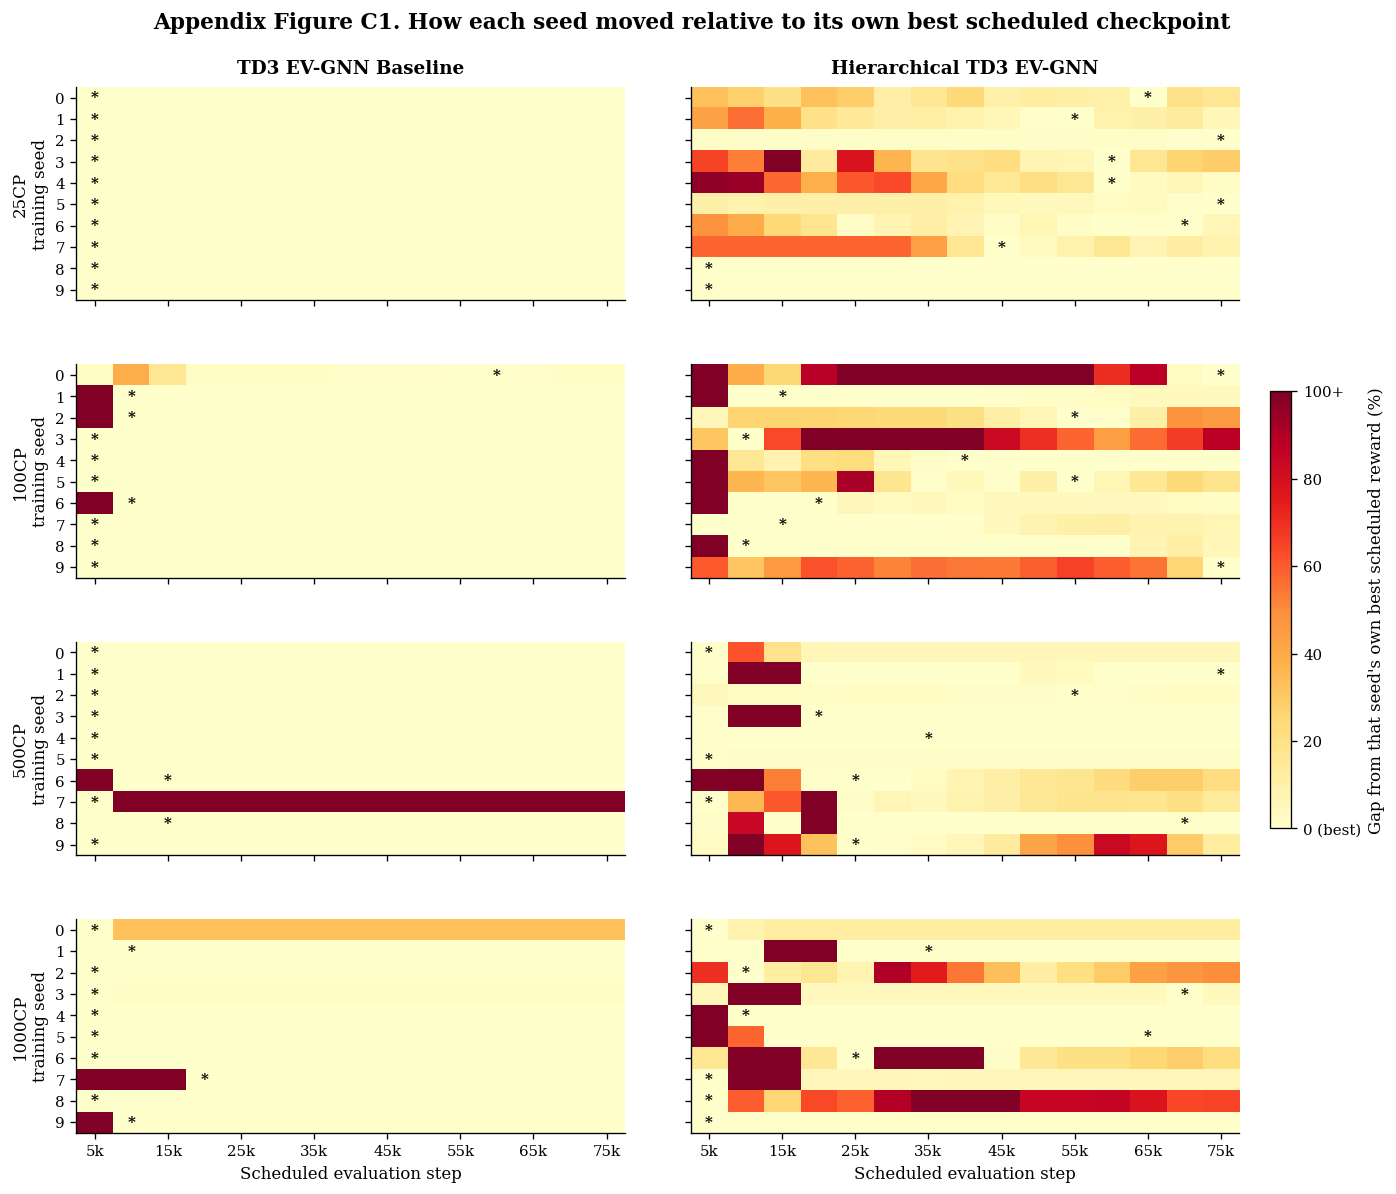

In [25]:
fig, axes = plt.subplots(4, 2, figsize=(12.5, 10.5), sharex=True, sharey=True)
fig.subplots_adjust(left=0.09, right=0.90, top=0.91, bottom=0.08, hspace=0.30, wspace=0.12)

last_image = None

for row, scale in enumerate(SCALE_ORDER):
    for col, model in enumerate(MODEL_ORDER):
        ax = axes[row, col]
        d = scheduled[(scheduled["scale"] == scale) & (scheduled["model"] == model)]

        pivot = (
            d.pivot(index="training_seed", columns="timestep", values="eval/mean_reward")
             .sort_index()
             .sort_index(axis=1)
        )

        values = pivot.to_numpy(dtype=float)
        best = np.nanmax(values, axis=1, keepdims=True)
        denominator = np.maximum(np.abs(best), 1e-12)
        relative_gap = 100.0 * (best - values) / denominator
        relative_gap = np.maximum(relative_gap, 0.0)

        last_image = ax.imshow(
            np.clip(relative_gap, 0, 100),
            aspect="auto",
            vmin=0,
            vmax=100,
            cmap="YlOrRd",
            interpolation="nearest",
        )

        # Mark the earliest checkpoint attaining the maximum reward for each seed.
        # np.nanargmax returns the first maximum, matching the idxmax rule used
        # in the checkpoint-selection summary table.
        for seed_row in range(relative_gap.shape[0]):
            best_col = int(np.nanargmax(values[seed_row]))
            ax.text(
                best_col,
                seed_row,
                "*",
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold",
                color="black",
            )

        if row == 0:
            ax.set_title(model, pad=8, fontweight="semibold")

        if col == 0:
            ax.set_ylabel(f"{SCALE_LABELS[scale]}\ntraining seed")
            ax.set_yticks(range(10), range(10))
        else:
            ax.tick_params(labelleft=False)

        if row == len(SCALE_ORDER) - 1:
            tick_idx = np.arange(0, len(pivot.columns), 2)
            ax.set_xticks(
                tick_idx,
                [f"{int(pivot.columns[i] / 1000)}k" for i in tick_idx],
            )
            ax.set_xlabel("Scheduled evaluation step")

        ax.set_facecolor("white")

cbar = fig.colorbar(
    last_image,
    ax=axes.ravel().tolist(),
    fraction=0.018,
    pad=0.025,
)
cbar.set_label("Gap from that seed's own best scheduled reward (%)")
cbar.set_ticks([0, 20, 40, 60, 80, 100])
cbar.set_ticklabels(["0 (best)", "20", "40", "60", "80", "100+"])

fig.suptitle(
    "Appendix Figure C1. How each seed moved relative to its own best scheduled checkpoint",
    fontsize=13,
    fontweight="bold",
    y=0.97,
)
plt.show()


# Appendix D - Allocation concentration distributions

The main text reports the mean HHI shift because it is the most direct concentration summary. This appendix retains the full transformer/charger **HHI and Gini** distributions so that the mechanism can be inspected without turning concentration into a performance score.

For each scenario and architecture, the translucent violin uses all 300 diagnostic episodes descriptively, while the overlaid points are the 10 seed-level policy means. Each scenario is given its own panel so that raw HHI/Gini values are compared **within scenario**, consistent with the entity-count caution in the main text.

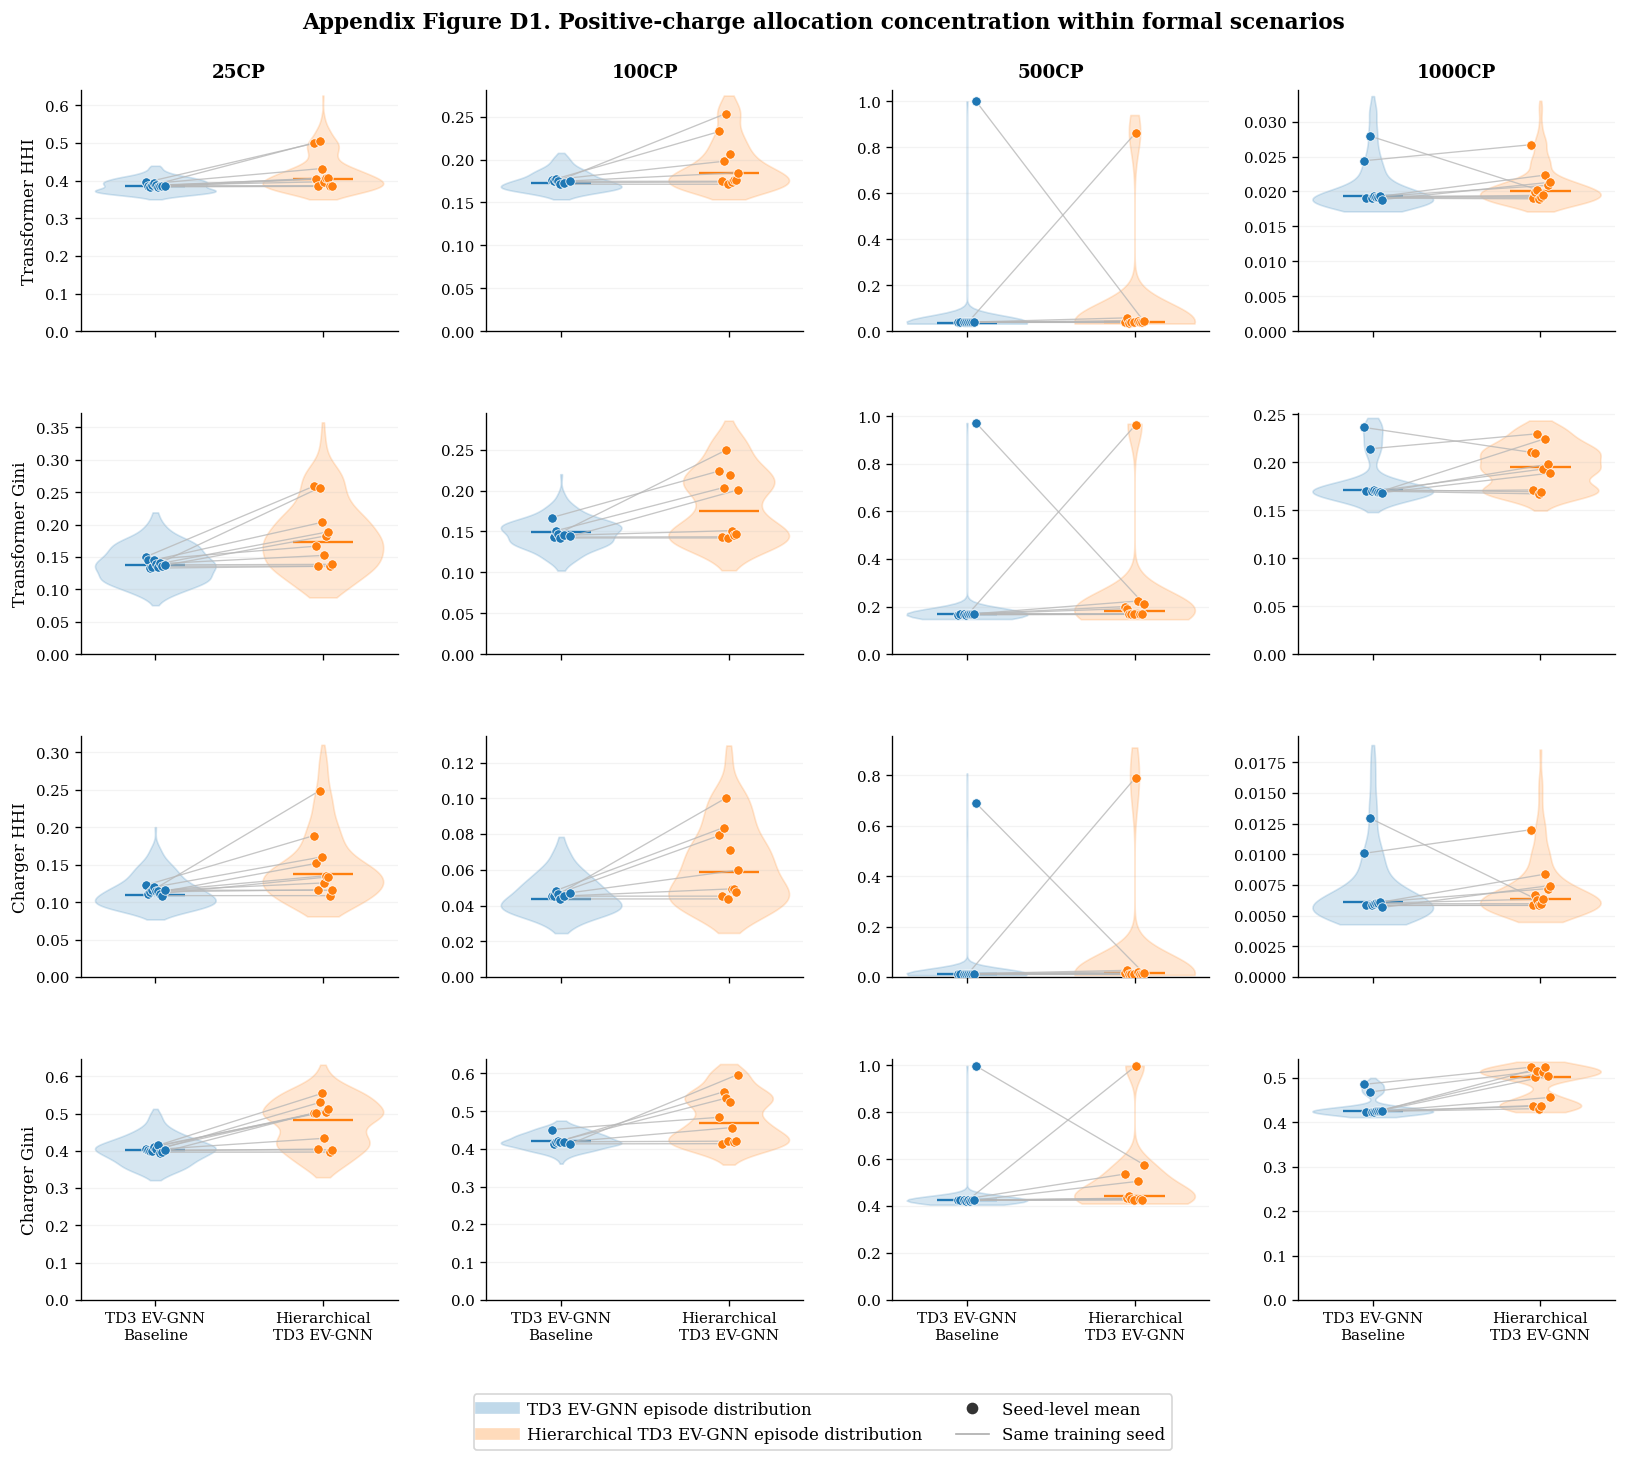

In [26]:
# Appendix Figure D1: episode distributions plus paired seed means for HHI/Gini.
allocation_specs = [
    ("transformer_positive_charge_action_hhi_mean", "Transformer HHI"),
    ("transformer_positive_charge_action_gini_mean", "Transformer Gini"),
    ("charger_positive_charge_action_hhi_mean", "Charger HHI"),
    ("charger_positive_charge_action_gini_mean", "Charger Gini"),
]

fig, axes = plt.subplots(4, 4, figsize=(16.5, 12.0))
for row, (metric, label) in enumerate(allocation_specs):
    for col, scale in enumerate(SCALE_ORDER):
        ax = axes[row, col]
        paired_violin(
            ax,
            diagnostics[diagnostics["scale"] == scale],
            seed_performance[seed_performance["scale"] == scale],
            metric,
            percent=False,
        )
        if row == 0:
            ax.set_title(SCALE_LABELS[scale], pad=8)
        if col == 0:
            ax.set_ylabel(label)
        ax.set_ylim(bottom=0)
        if row < len(allocation_specs) - 1:
            ax.set_xticklabels([])

handles = [
    Line2D([0], [0], color=MODEL_COLOUR[MODEL_ORDER[0]], lw=7, alpha=0.28,
           label="TD3 EV-GNN episode distribution"),
    Line2D([0], [0], color=MODEL_COLOUR[MODEL_ORDER[1]], lw=7, alpha=0.28,
           label="Hierarchical TD3 EV-GNN episode distribution"),
    Line2D([0], [0], marker="o", linestyle="", markersize=6, color="0.20",
           label="Seed-level mean"),
    Line2D([0], [0], color="0.68", linewidth=1.0, label="Same training seed"),
]
fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.01),
           ncol=2, frameon=True)
fig.suptitle("Appendix Figure D1. Positive-charge allocation concentration within formal scenarios",
             fontsize=13, fontweight="bold", y=0.995)
fig.subplots_adjust(bottom=0.10, top=0.94, hspace=0.34, wspace=0.28)
plt.show()


## Observed allocation-distribution pattern

The detailed distributions reinforce the HHI summary in the main text. At **25CP and 100CP**, the hierarchical transformer and charger distributions are generally shifted toward greater concentration/inequality. At **500CP**, transformer HHI is lower under the hierarchy on average while charger-level concentration remains similar; isolated near-maximum outliers in both architectures show why the seed distribution matters. At **1000CP**, HHI distributions largely overlap, while charger Gini remains somewhat higher under the hierarchy.

The broad mechanism is therefore **not** “hierarchy always spreads allocation more evenly”. Its effect on allocation concentration depends on infrastructure level and formal scenario. HHI/Gini remain descriptive mechanism evidence and should not be interpreted as direct operational superiority.